# Cuisine Classification Using Recipe Ingredients

## A Machine Learning Classification Project

### Project Overview

Food recipes contain combinations of ingredients that often reflect the culinary traditions from which they originate. This project investigates whether the cuisine associated with a recipe can be predicted automatically based on the ingredients used in preparing it.

The analysis uses a dataset containing 57,691 recipes, where each recipe is associated with a cuisine and represented by the presence or absence of 384 different ingredients. The project applies the data science methodology from problem definition and data understanding through data preparation, modelling, and evaluation.

The primary objective is to develop a machine learning classification model capable of predicting the cuisine of a recipe from its ingredient profile and to evaluate how accurately the model distinguishes between different cuisines.

### Project Origin

This project was developed as an extension of concepts introduced during the IBM Data Science Professional Certificate. The original course exercises have been reorganized, independently documented, and extended into an end-to-end portfolio project.

### Tools and Technologies

* Python

* Jupyter Notebook

* Pandas

* NumPy

* Matplotlib

* Scikit-learn

## 1. Business Understanding

### 1.1 Business Problem

Recipes from different culinary traditions are often distinguished by the ingredients and combinations of ingredients they use. However, manually identifying the cuisine associated with a recipe can be difficult when only the ingredient list is available.

A data-driven classification approach could help determine whether patterns in recipe ingredients are sufficiently distinctive to automatically identify the cuisine associated with a recipe.

### 1.2 Project Objective

The objective of this project is to explore the relationship between recipe ingredients and cuisine type and to develop a machine learning classification model that can predict the cuisine of a recipe based on its ingredient profile.

### 1.3 Analytical Question

Can the cuisine of a recipe be automatically predicted from the ingredients used in the recipe?

### 1.4 Data Science Approach

This problem will be treated as a **supervised multiclass classification problem** because the dataset contains known cuisine labels and multiple possible cuisine categories. Recipe ingredients will be used as predictor variables, while cuisine will serve as the target variable.

The project will follow an iterative data science workflow involving:

* Data understanding

* Data preparation

* Exploratory data analysis

* Model development

* Model evaluation

* Interpretation of findings

## 2. Data Understanding

### 2.1 Data Source

The dataset used in this project originates from research by **Yong-Yeol Ahn and colleagues** on food pairing and culinary patterns. Recipe information was collected from multiple online recipe sources, including **Allrecipes, Epicurious, and Menupan**, and was subsequently made available for use in the IBM Data Science course exercises.

The original research is documented in: Ahn, Y.-Y., Ahnert, S. E., Bagrow, J. P., & Barabási, A.-L. (2011). Flavor network and the principles of food pairing. Scientific Reports, 1, 196.

Research resource: http://yongyeol.com/pape

### 2.2 Dataset Description

The dataset contains 57,691 recipes. Each row represents an individual recipe.

The dataset includes:

* A cuisine variable identifying the culinary tradition associated with each recipe.

* 383 ingredient variables indicating whether particular ingredients are present in each recipe.

* Ingredient variables are represented primarily as binary indicators showing the presence or absence of an ingredient.

The cuisine variable will serve as the target variable, while the ingredient variables will serve as the predictor features used to classify recipes.

### 2.3 Unit of Analysis

The unit of analysis is an individual recipe.

Each observation therefore represents one recipe together with:

* its known cuisine; and

* its ingredient profile.

### 2.4 Initial Data Requirements

To address the analytical question, the dataset must contain:

* A valid cuisine label for each recipe.

* Consistently coded ingredient information.

* Sufficient observations for each cuisine considered in the analysis.

* Ingredient variables suitable for use as machine learning features.

## 3. Data Loading and Initial Inspection

### 3.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Display all dataframe columns when required
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

# Identify the project root regardless of where Jupyter starts
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()

# Define project folders and files
data_path = project_root / "data" / "recipes.csv"
images_dir = project_root / "images"

# Ensure the images folder exists
images_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Dataset found:", data_path.exists())
print("Images folder:", images_dir)

Project root: C:\Users\mikem\Documents\IBM Data Science Professional Certificate\3-Data Science Methodology\cuisine-classification
Dataset found: True
Images folder: C:\Users\mikem\Documents\IBM Data Science Professional Certificate\3-Data Science Methodology\cuisine-classification\images


In [3]:
file_size_mb = data_path.stat().st_size / (1024 * 1024)

print(f"recipes.csv size: {file_size_mb:.2f} MB")

recipes.csv size: 64.17 MB


### 3.2 Load the Dataset

In [3]:
recipes = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", recipes.shape)

Dataset loaded successfully.
Dataset shape: (57691, 384)


### 3.3 Initial Dataset Inspection

In [4]:
# Display the dataset dimensions
print("Dataset shape:", recipes.shape)

# Display column names
print("\nNumber of columns:", len(recipes.columns))

# Display the first 10 column names
print("\nFirst 10 columns:")
print(recipes.columns[:10].tolist())

Dataset shape: (57691, 384)

Number of columns: 384

First 10 columns:
['country', 'almond', 'angelica', 'anise', 'anise_seed', 'apple', 'apple_brandy', 'apricot', 'armagnac', 'artemisia']


In [6]:
# Display the first five observations
recipes.head()

,country,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,asparagus,avocado,bacon,baked_potato,balm,banana,barley,bartlett_pear,basil,bay,bean,beech,beef,beef_broth,beef_liver,beer,beet,bell_pepper,bergamot,berry,bitter_orange,black_bean,black_currant,black_mustard_seed_oil,black_pepper,black_raspberry,black_sesame_seed,black_tea,blackberry,blackberry_brandy,blue_cheese,blueberry,bone_oil,bourbon_whiskey,brandy,brassica,bread,broccoli,brown_rice,brussels_sprout,buckwheat,butter,buttermilk,cabbage,cabernet_sauvignon_wine,cacao,camembert_cheese,cane_molasses,caraway,cardamom,carnation,carob,carrot,cashew,cassava,catfish,cauliflower,caviar,cayenne,celery,celery_oil,cereal,chamomile,champagne_wine,chayote,cheddar_cheese,cheese,cherry,cherry_brandy,chervil,chicken,chicken_broth,chicken_liver,chickpea,chicory,chinese_cabbage,chive,cider,cilantro,cinnamon,citrus,citrus_peel,clam,clove,cocoa,coconut,coconut_oil,cod,coffee,cognac,concord_grape,condiment,coriander,corn,corn_flake,corn_grit,cottage_cheese,crab,cranberry,cream,cream_cheese,cucumber,cumin,cured_pork,currant,date,dill,durian,eel,egg,egg_noodle,elderberry,emmental_cheese,endive,enokidake,fennel,fenugreek,feta_cheese,fig,fish,flower,frankfurter,fruit,galanga,gardenia,garlic,gelatin,geranium,gin,ginger,goat_cheese,grape,grape_brandy,grape_juice,grapefruit,green_bell_pepper,green_tea,gruyere_cheese,guava,haddock,ham,hazelnut,herring,holy_basil,honey,hop,horseradish,huckleberry,jamaican_rum,japanese_plum,jasmine,jasmine_tea,juniper_berry,kaffir_lime,kale,katsuobushi,kelp,kidney_bean,kiwi,kohlrabi,kumquat,lamb,lard,laurel,lavender,leaf,leek,lemon,lemon_juice,lemon_peel,lemongrass,lentil,lettuce,licorice,lilac_flower_oil,lima_bean,lime,lime_juice,lime_peel_oil,lingonberry,litchi,liver,lobster,long_pepper,lovage,macadamia_nut,macaroni,mace,mackerel,malt,mandarin,mandarin_peel,mango,maple_syrup,marjoram,mate,matsutake,meat,melon,milk,milk_fat,mint,mozzarella_cheese,mung_bean,munster_cheese,muscat_grape,mushroom,mussel,mustard,mutton,nectarine,nira,nut,nutmeg,oat,oatmeal,octopus,okra,olive,olive_oil,onion,orange,orange_flower,orange_juice,orange_peel,oregano,ouzo,oyster,palm,papaya,parmesan_cheese,parsley,parsnip,passion_fruit,pea,peach,peanut,peanut_butter,peanut_oil,pear,pear_brandy,pecan,pelargonium,pepper,peppermint,peppermint_oil,pimenta,pimento,pineapple,pistachio,plum,popcorn,porcini,pork,pork_liver,pork_sausage,port_wine,potato,potato_chip,prawn,prickly_pear,provolone_cheese,pumpkin,quince,radish,raisin,rapeseed,raspberry,raw_beef,red_algae,red_bean,red_kidney_bean,red_wine,rhubarb,rice,roasted_almond,roasted_beef,roasted_hazelnut,roasted_meat,roasted_nut,roasted_peanut,roasted_pecan,roasted_pork,roasted_sesame_seed,romano_cheese,root,roquefort_cheese,rose,rosemary,rum,rutabaga,rye_bread,rye_flour,saffron,sage,sake,salmon,salmon_roe,sassafras,sauerkraut,savory,scallion,scallop,sea_algae,seaweed,seed,sesame_oil,sesame_seed,shallot,sheep_cheese,shellfish,sherry,shiitake,shrimp,smoke,smoked_fish,smoked_salmon,smoked_sausage,sour_cherry,sour_milk,soy_sauce,soybean,soybean_oil,spearmint,squash,squid,star_anise,starch,strawberry,strawberry_jam,strawberry_juice,sturgeon_caviar,sumac,sunflower_oil,sweet_potato,swiss_cheese,tabasco_pepper,tamarind,tangerine,tarragon,tea,tequila,thai_pepper,thyme,tomato,tomato_juice,truffle,tuna,turkey,turmeric,turnip,vanilla,veal,vegetable,vegetable_oil,vinegar,violet,walnut,wasabi,watercress,watermelon,wheat,wheat_bread,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,Vietnamese,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,

In [7]:
# Inspect data types and non-null values
recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57691 entries, 0 to 57690
Columns: 384 entries, country to zucchini
dtypes: object(384)
memory usage: 169.0+ MB


In [8]:
print("Dataset shape:", recipes.shape)
print("First column:", recipes.columns[0])

Dataset shape: (57691, 384)
First column: country


## 4. Data Quality Assessment

Before preparing the dataset for modelling, the data will be assessed for potential quality issues, including missing values, duplicate records, inconsistent cuisine labels, and inconsistent ingredient coding.

In [9]:
# Check for missing values
total_missing = recipes.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


In [10]:
# Check for duplicate records
duplicate_rows = recipes.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 4724


In [11]:
# Check the number of unique cuisine labels
print("Number of unique cuisine labels:", recipes["country"].nunique())

# Display cuisine labels and their frequencies
recipes["country"].value_counts()

Number of unique cuisine labels: 69


country
American        40150
Mexico           1754
Italian          1715
Italy            1461
Asian            1176
                ...  
Indonesia          12
Belgium            11
East-African       11
Israel              9
Bangladesh          4
Name: count, Length: 69, dtype: int64

### 4.1 Cuisine Label Assessment

In [12]:
# Create a table of all cuisine labels and their frequencies
cuisine_counts = (recipes["country"]
    .value_counts()
    .rename_axis("cuisine_label")
    .reset_index(name="recipe_count"))

cuisine_counts

,cuisine_label,recipe_count
0,American,40150
1,Mexico,1754
2,Italian,1715
3,Italy,1461
4,Asian,1176
...,...,...
64,Indonesia,12
65,Belgium,11
66,East-African,11
67,Israel,9


In [13]:
# Display cuisine labels alphabetically to identify naming inconsistencies
sorted(recipes["country"].unique())

['African',
 'American',
 'Asian',
 'Austria',
 'Bangladesh',
 'Belgium',
 'Cajun_Creole',
 'Canada',
 'Caribbean',
 'Central_SouthAmerican',
 'China',
 'Chinese',
 'East-African',
 'Eastern-Europe',
 'EasternEuropean_Russian',
 'English_Scottish',
 'France',
 'French',
 'German',
 'Germany',
 'Greek',
 'India',
 'Indian',
 'Indonesia',
 'Iran',
 'Irish',
 'Israel',
 'Italian',
 'Italy',
 'Japan',
 'Japanese',
 'Jewish',
 'Korea',
 'Lebanon',
 'Malaysia',
 'Mediterranean',
 'Mexican',
 'Mexico',
 'MiddleEastern',
 'Moroccan',
 'Netherlands',
 'North-African',
 'Pakistan',
 'Philippines',
 'Portugal',
 'Scandinavia',
 'Scandinavian',
 'South-African',
 'South-America',
 'Southern_SoulFood',
 'Southwestern',
 'Spain',
 'Spanish_Portuguese',
 'Switzerland',
 'Thai',
 'Thailand',
 'Turkey',
 'UK-and-Ireland',
 'Vietnam',
 'Vietnamese',
 'West-African',
 'asian',
 'chinese',
 'east_asian',
 'italian',
 'japanese',
 'korean',
 'mexico',
 'western']

## 5. Data Preparation

### 5.1 Standardizing Cuisine Labels

The original target variable contains inconsistent naming conventions, including country names, cuisine names, and differences in capitalization. To improve consistency, the target variable will be renamed from `country` to `cuisine`, converted to lowercase, and clearly equivalent labels will be consolidated.

In [14]:
# Create a working copy so that the original loaded data remains unchanged
recipes_clean = recipes.copy()

# Rename the target variable
recipes_clean = recipes_clean.rename(columns={"country": "cuisine"})

# Convert cuisine labels to lowercase
recipes_clean["cuisine"] = recipes_clean["cuisine"].str.lower()

# Standardize clearly equivalent cuisine labels
cuisine_mapping = {
    "austria": "austrian",
    "belgium": "belgian",
    "canada": "canadian",
    "china": "chinese",
    "france": "french",
    "germany": "german",
    "india": "indian",
    "indonesia": "indonesian",
    "iran": "iranian",
    "italy": "italian",
    "israel": "jewish",
    "japan": "japanese",
    "korea": "korean",
    "lebanon": "lebanese",
    "malaysia": "malaysian",
    "mexico": "mexican",
    "netherlands": "dutch",
    "pakistan": "pakistani",
    "philippines": "philippine",
    "scandinavia": "scandinavian",
    "spain": "spanish_portuguese",
    "portugal": "spanish_portuguese",
    "switzerland": "swiss",
    "thailand": "thai",
    "turkey": "turkish",
    "vietnam": "vietnamese",
    "uk-and-ireland": "uk-and-irish",
    "irish": "uk-and-irish"
}

recipes_clean["cuisine"] = (
    recipes_clean["cuisine"]
    .replace(cuisine_mapping)
)

In [15]:
print("Original unique labels:", recipes["country"].nunique())
print("Standardized unique labels:", recipes_clean["cuisine"].nunique())

sorted(recipes_clean["cuisine"].unique())

Original unique labels: 69
Standardized unique labels: 49


['african',
 'american',
 'asian',
 'austrian',
 'bangladesh',
 'belgian',
 'cajun_creole',
 'canadian',
 'caribbean',
 'central_southamerican',
 'chinese',
 'dutch',
 'east-african',
 'east_asian',
 'eastern-europe',
 'easterneuropean_russian',
 'english_scottish',
 'french',
 'german',
 'greek',
 'indian',
 'indonesian',
 'iranian',
 'italian',
 'japanese',
 'jewish',
 'korean',
 'lebanese',
 'malaysian',
 'mediterranean',
 'mexican',
 'middleeastern',
 'moroccan',
 'north-african',
 'pakistani',
 'philippine',
 'scandinavian',
 'south-african',
 'south-america',
 'southern_soulfood',
 'southwestern',
 'spanish_portuguese',
 'swiss',
 'thai',
 'turkish',
 'uk-and-irish',
 'vietnamese',
 'west-african',
 'western']

### 5.2 Assessing Cuisine Class Frequencies

Following label standardization, the distribution of recipes across cuisine categories is examined to identify classes with very few observations. Extremely small classes may provide insufficient data for reliable model training and evaluation.

In [16]:
# Count recipes in each standardized cuisine category
standardized_counts = recipes_clean["cuisine"].value_counts()

# Display all cuisine frequencies
standardized_counts

cuisine
american                   40150
italian                     3250
mexican                     2390
french                      1264
asian                       1193
east_asian                   951
korean                       799
canadian                     774
indian                       598
western                      450
chinese                      442
spanish_portuguese           416
uk-and-irish                 368
southern_soulfood            346
jewish                       329
japanese                     320
german                       289
thai                         289
mediterranean                289
scandinavian                 250
middleeastern                248
central_southamerican        241
eastern-europe               235
greek                        225
english_scottish             204
caribbean                    183
cajun_creole                 146
easterneuropean_russian      146
moroccan                     137
african                      115
so

In [17]:
# Identify cuisines with 50 or fewer recipes
rare_cuisines = standardized_counts[standardized_counts <= 50]

print("Number of cuisines with 50 or fewer recipes:", len(rare_cuisines))
print("Total recipes in these rare cuisines:", rare_cuisines.sum())

rare_cuisines

Number of cuisines with 50 or fewer recipes: 15
Total recipes in these rare cuisines: 288


cuisine
philippine       43
dutch            32
lebanese         31
iranian          21
austrian         21
swiss            20
pakistani        19
malaysian        18
south-african    16
turkish          16
west-african     13
indonesian       12
belgian          11
east-african     11
bangladesh        4
Name: count, dtype: int64

### 5.3 Filtering Rare Cuisine Categories

Following standardization, 15 cuisine categories contained 50 or fewer recipes, representing 288 observations in total. These categories have relatively few observations for reliable model training and evaluation.

For this analysis, cuisine categories with more than 50 recipes will therefore be retained. This threshold reduces the influence of extremely small classes while preserving the overwhelming majority of observations in the dataset.

In [18]:
# Retain cuisine categories with more than 50 recipes
cuisine_counts = recipes_clean["cuisine"].value_counts()

cuisines_to_keep = cuisine_counts[cuisine_counts > 50].index

recipes_clean = recipes_clean[
    recipes_clean["cuisine"].isin(cuisines_to_keep)
].copy()

# Reset the dataframe index
recipes_clean.reset_index(drop=True, inplace=True)

In [19]:
print("Original number of recipes:", len(recipes))
print("Recipes after filtering:", len(recipes_clean))
print("Recipes removed:", len(recipes) - len(recipes_clean))

print("\nNumber of cuisine categories retained:",
      recipes_clean["cuisine"].nunique())

print("\nSmallest retained cuisine:")
print(recipes_clean["cuisine"].value_counts().tail())

Original number of recipes: 57691
Recipes after filtering: 57403
Recipes removed: 288

Number of cuisine categories retained: 34

Smallest retained cuisine:
cuisine
african          115
southwestern     108
south-america    103
vietnamese        95
north-african     60
Name: count, dtype: int64


### 5.4 Validating Ingredient Variables

The ingredient variables are inspected to confirm that they are consistently coded before conversion into numeric binary features for machine learning.

In [20]:
# Separate the ingredient columns from the target variable
ingredient_columns = recipes_clean.columns.drop("cuisine")

print("Number of ingredient variables:", len(ingredient_columns))

# Identify all unique values appearing across ingredient columns
ingredient_values = pd.unique(
    recipes_clean[ingredient_columns].values.ravel()
)

print("Unique ingredient values:", ingredient_values)

Number of ingredient variables: 383
Unique ingredient values: ['No' 'Yes']


In [21]:
# Check data types of the ingredient variables
recipes_clean[ingredient_columns].dtypes.value_counts()

object    383
Name: count, dtype: int64

### 5.5 Converting Ingredient Variables to Binary Format

The ingredient variables are currently recorded as `Yes` and `No`. For machine learning, these categorical indicators are converted into numeric binary values, where:

- `Yes = 1`
- `No = 0`

In [22]:
# Convert ingredient indicators from Yes/No to 1/0
recipes_clean[ingredient_columns] = (
    recipes_clean[ingredient_columns]
    .replace({"Yes": 1, "No": 0})
    .astype("int8")
)

C:\Users\mikem\AppData\Local\Temp\ipykernel_24572\3585263412.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"Yes": 1, "No": 0})


In [23]:
print("Unique ingredient values after conversion:",
      pd.unique(recipes_clean[ingredient_columns].values.ravel()))

print("\nIngredient data types:")
print(recipes_clean[ingredient_columns].dtypes.value_counts())

Unique ingredient values after conversion: [0 1]

Ingredient data types:
int8    383
Name: count, dtype: int64


In [24]:
recipes_clean.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,asparagus,avocado,bacon,baked_potato,balm,banana,barley,bartlett_pear,basil,bay,bean,beech,beef,beef_broth,beef_liver,beer,beet,bell_pepper,bergamot,berry,bitter_orange,black_bean,black_currant,black_mustard_seed_oil,black_pepper,black_raspberry,black_sesame_seed,black_tea,blackberry,blackberry_brandy,blue_cheese,blueberry,bone_oil,bourbon_whiskey,brandy,brassica,bread,broccoli,brown_rice,brussels_sprout,buckwheat,butter,buttermilk,cabbage,cabernet_sauvignon_wine,cacao,camembert_cheese,cane_molasses,caraway,cardamom,carnation,carob,carrot,cashew,cassava,catfish,cauliflower,caviar,cayenne,celery,celery_oil,cereal,chamomile,champagne_wine,chayote,cheddar_cheese,cheese,cherry,cherry_brandy,chervil,chicken,chicken_broth,chicken_liver,chickpea,chicory,chinese_cabbage,chive,cider,cilantro,cinnamon,citrus,citrus_peel,clam,clove,cocoa,coconut,coconut_oil,cod,coffee,cognac,concord_grape,condiment,coriander,corn,corn_flake,corn_grit,cottage_cheese,crab,cranberry,cream,cream_cheese,cucumber,cumin,cured_pork,currant,date,dill,durian,eel,egg,egg_noodle,elderberry,emmental_cheese,endive,enokidake,fennel,fenugreek,feta_cheese,fig,fish,flower,frankfurter,fruit,galanga,gardenia,garlic,gelatin,geranium,gin,ginger,goat_cheese,grape,grape_brandy,grape_juice,grapefruit,green_bell_pepper,green_tea,gruyere_cheese,guava,haddock,ham,hazelnut,herring,holy_basil,honey,hop,horseradish,huckleberry,jamaican_rum,japanese_plum,jasmine,jasmine_tea,juniper_berry,kaffir_lime,kale,katsuobushi,kelp,kidney_bean,kiwi,kohlrabi,kumquat,lamb,lard,laurel,lavender,leaf,leek,lemon,lemon_juice,lemon_peel,lemongrass,lentil,lettuce,licorice,lilac_flower_oil,lima_bean,lime,lime_juice,lime_peel_oil,lingonberry,litchi,liver,lobster,long_pepper,lovage,macadamia_nut,macaroni,mace,mackerel,malt,mandarin,mandarin_peel,mango,maple_syrup,marjoram,mate,matsutake,meat,melon,milk,milk_fat,mint,mozzarella_cheese,mung_bean,munster_cheese,muscat_grape,mushroom,mussel,mustard,mutton,nectarine,nira,nut,nutmeg,oat,oatmeal,octopus,okra,olive,olive_oil,onion,orange,orange_flower,orange_juice,orange_peel,oregano,ouzo,oyster,palm,papaya,parmesan_cheese,parsley,parsnip,passion_fruit,pea,peach,peanut,peanut_butter,peanut_oil,pear,pear_brandy,pecan,pelargonium,pepper,peppermint,peppermint_oil,pimenta,pimento,pineapple,pistachio,plum,popcorn,porcini,pork,pork_liver,pork_sausage,port_wine,potato,potato_chip,prawn,prickly_pear,provolone_cheese,pumpkin,quince,radish,raisin,rapeseed,raspberry,raw_beef,red_algae,red_bean,red_kidney_bean,red_wine,rhubarb,rice,roasted_almond,roasted_beef,roasted_hazelnut,roasted_meat,roasted_nut,roasted_peanut,roasted_pecan,roasted_pork,roasted_sesame_seed,romano_cheese,root,roquefort_cheese,rose,rosemary,rum,rutabaga,rye_bread,rye_flour,saffron,sage,sake,salmon,salmon_roe,sassafras,sauerkraut,savory,scallion,scallop,sea_algae,seaweed,seed,sesame_oil,sesame_seed,shallot,sheep_cheese,shellfish,sherry,shiitake,shrimp,smoke,smoked_fish,smoked_salmon,smoked_sausage,sour_cherry,sour_milk,soy_sauce,soybean,soybean_oil,spearmint,squash,squid,star_anise,starch,strawberry,strawberry_jam,strawberry_juice,sturgeon_caviar,sumac,sunflower_oil,sweet_potato,swiss_cheese,tabasco_pepper,tamarind,tangerine,tarragon,tea,tequila,thai_pepper,thyme,tomato,tomato_juice,truffle,tuna,turkey,turmeric,turnip,vanilla,veal,vegetable,vegetable_oil,vinegar,violet,walnut,wasabi,watercress,watermelon,wheat,wheat_bread,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,vietnamese,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,

### 5.6 Data Preparation Summary

The data preparation process resulted in the following changes:

- The original dataset contained **57,691 recipes and 384 variables**.
- The target variable was renamed from `country` to `cuisine`.
- Cuisine labels were converted to lowercase and clearly equivalent labels were consolidated.
- The number of unique cuisine labels was reduced from **69 to 49** after standardization.
- Cuisine categories containing **50 or fewer recipes** were excluded to provide sufficient observations for model development and evaluation.
- A total of **288 recipes** belonging to 15 rare cuisine categories were removed.
- The resulting analytical dataset contains **57,403 recipes across 34 cuisine categories**.
- The **383 ingredient variables** were converted from `Yes`/`No` values to binary `1`/`0` indicators.
- No missing values were identified in the original dataset.
- A total of **4,724 identical rows** were identified. These were not automatically removed because identical ingredient profiles may represent separate recipes rather than erroneous duplicate records.

The prepared dataset is now suitable for exploratory analysis and subsequent machine learning modelling.

## 6. Exploratory Data Analysis

### 6.1 Distribution of Cuisine Categories

The distribution of recipes across cuisine categories is examined to understand class representation and identify potential class imbalance before model development.

# Count recipes in each cuisine category
cuisine_distribution = recipes_clean["cuisine"].value_counts()

cuisine_distribution

### 6.2 Cuisine Proportions and Class Imbalance

The cuisine distribution is highly uneven. To quantify the extent of class imbalance, the proportion of the dataset represented by each cuisine category is calculated.

In [25]:
# Calculate cuisine proportions
cuisine_proportions = (
    recipes_clean["cuisine"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cuisine_proportions

cuisine
american                   69.94
italian                     5.66
mexican                     4.16
french                      2.20
asian                       2.08
east_asian                  1.66
korean                      1.39
canadian                    1.35
indian                      1.04
western                     0.78
chinese                     0.77
spanish_portuguese          0.72
uk-and-irish                0.64
southern_soulfood           0.60
jewish                      0.57
japanese                    0.56
mediterranean               0.50
thai                        0.50
german                      0.50
scandinavian                0.44
middleeastern               0.43
central_southamerican       0.42
eastern-europe              0.41
greek                       0.39
english_scottish            0.36
caribbean                   0.32
easterneuropean_russian     0.25
cajun_creole                0.25
moroccan                    0.24
african                     0.20
so

In [26]:
# Display the five largest cuisine categories by percentage
cuisine_proportions.head()

cuisine
american    69.94
italian      5.66
mexican      4.16
french       2.20
asian        2.08
Name: proportion, dtype: float64

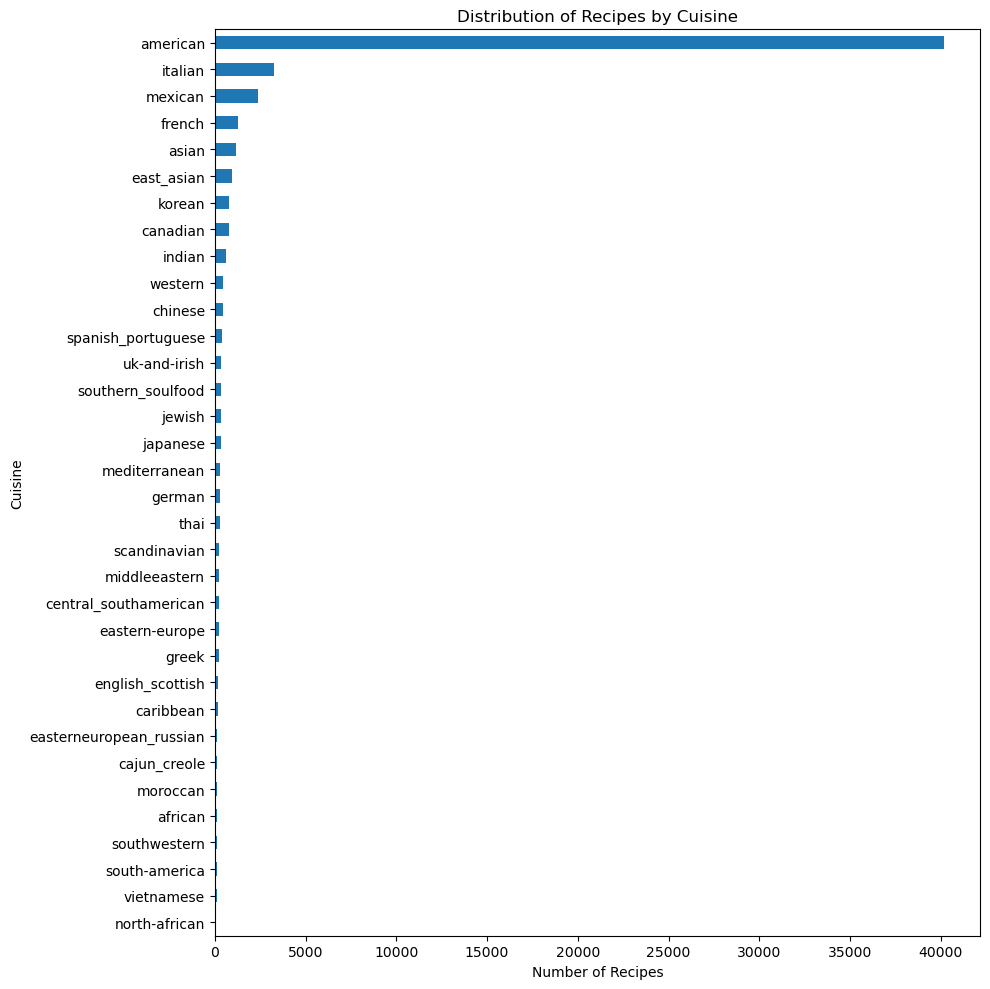

In [27]:
cuisine_distribution = recipes_clean["cuisine"].value_counts()

plt.figure(figsize=(10, 10))

cuisine_distribution.sort_values().plot(kind="barh")

plt.title("Distribution of Recipes by Cuisine")
plt.xlabel("Number of Recipes")
plt.ylabel("Cuisine")
plt.tight_layout()

plt.savefig(
    images_dir / "cuisine_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The cuisine distribution is highly imbalanced. American recipes represent approximately 70% of the analytical dataset, while all other cuisine categories individually account for much smaller proportions.

This imbalance has important implications for model evaluation. Overall accuracy alone may provide an incomplete assessment of model performance because a classifier could achieve a relatively high accuracy by disproportionately predicting the dominant American class. Consequently, additional evaluation measures such as precision, recall, F1-score, and the confusion matrix will be considered during model evaluation.

### 6.3 Most Frequently Used Ingredients

The frequency of individual ingredients is examined to identify the ingredients that occur most commonly across the recipes in the analytical dataset.

In [28]:
# Calculate how many recipes contain each ingredient
ingredient_frequency = (
    recipes_clean[ingredient_columns]
    .sum()
    .sort_values(ascending=False)
)

# Display the 20 most frequently used ingredients
ingredient_frequency.head(20)

egg              21025
wheat            20781
butter           20719
onion            18080
garlic           17353
milk             12870
vegetable_oil    11105
cream            10171
tomato            9920
olive_oil         9876
black_pepper      9828
pepper            9230
vanilla           9010
cayenne           8254
vinegar           8060
cane_molasses     7741
bell_pepper       5979
cinnamon          5594
parsley           5552
chicken           5436
dtype: int64

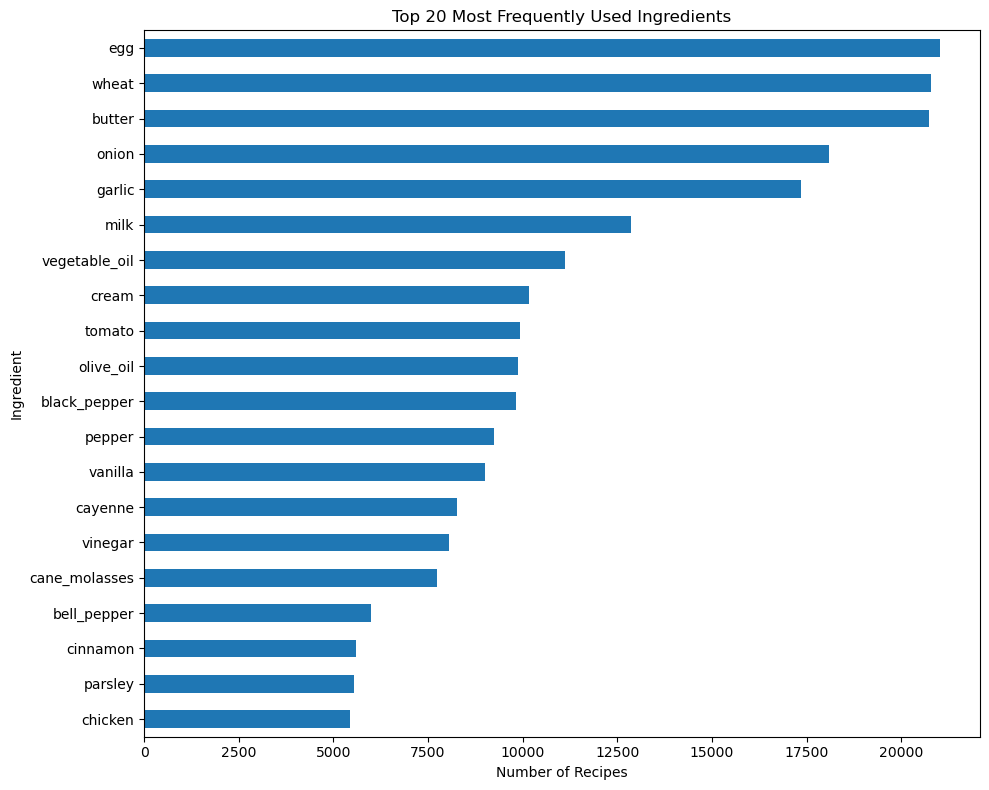

In [29]:
# Select the 20 most frequently used ingredients
top_20_ingredients = ingredient_frequency.head(20).sort_values()

plt.figure(figsize=(10, 8))

top_20_ingredients.plot(kind="barh")

plt.title("Top 20 Most Frequently Used Ingredients")
plt.xlabel("Number of Recipes")
plt.ylabel("Ingredient")
plt.tight_layout()

# Save the figure
plt.savefig(
    images_dir / "top_20_ingredients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
ingredient_frequency.head(10)

egg              21025
wheat            20781
butter           20719
onion            18080
garlic           17353
milk             12870
vegetable_oil    11105
cream            10171
tomato            9920
olive_oil         9876
dtype: int64

### 6.4 Ingredient Prevalence

To make ingredient frequencies easier to interpret, the proportion of recipes containing each ingredient is calculated as a percentage of the analytical dataset.

In [31]:
# Calculate ingredient prevalence as a percentage of all recipes
ingredient_prevalence = (
    ingredient_frequency / len(recipes_clean) * 100
).round(2)

# Display the 10 most prevalent ingredients
ingredient_prevalence.head(10)

egg              36.63
wheat            36.20
butter           36.09
onion            31.50
garlic           30.23
milk             22.42
vegetable_oil    19.35
cream            17.72
tomato           17.28
olive_oil        17.20
dtype: float64

In [32]:
# Combine frequency and prevalence for the top 10 ingredients
top_10_ingredients = pd.DataFrame({
    "recipe_count": ingredient_frequency.head(10),
    "prevalence_percent": ingredient_prevalence.head(10)
})

top_10_ingredients

,recipe_count,prevalence_percent
egg,21025,36.63
wheat,20781,36.20
butter,20719,36.09
onion,18080,31.50
garlic,17353,30.23
milk,12870,22.42
vegetable_oil,11105,19.35
cream,10171,17.72
tomato,9920,17.28
olive_oil,9876,17.20


### Interpretation

The ingredient prevalence analysis shows that a relatively small group of ingredients appears frequently across the recipe collection.

**Egg** is the most prevalent ingredient, appearing in 21,025 recipes, or **36.63%** of the analytical dataset. It is closely followed by **wheat (36.20%)** and **butter (36.09%)**. Onion and garlic are also common, appearing in **31.50%** and **30.23%** of recipes, respectively.

Other frequently occurring ingredients include milk, vegetable oil, cream, tomato, and olive oil.

These results indicate that many of the most common ingredients are shared across multiple culinary traditions. Consequently, overall ingredient frequency alone may not be sufficient for distinguishing cuisines. The next stage therefore examines ingredient patterns **within individual cuisine categories** to identify ingredients that may be more useful for classification.

### 6.5 Cuisine-Specific Ingredient Patterns

To identify ingredients that may help distinguish one cuisine from another, ingredient prevalence is calculated separately within each cuisine category.

In [33]:
# Calculate the mean of each binary ingredient variable within each cuisine
# Because ingredients are coded as 0/1, the mean represents the proportion
# of recipes in that cuisine containing the ingredient.

cuisine_ingredient_prevalence = (
    recipes_clean
    .groupby("cuisine")[ingredient_columns]
    .mean()
)

cuisine_ingredient_prevalence.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,asparagus,avocado,bacon,baked_potato,balm,banana,barley,bartlett_pear,basil,bay,bean,beech,beef,beef_broth,beef_liver,beer,beet,bell_pepper,bergamot,berry,bitter_orange,black_bean,black_currant,black_mustard_seed_oil,black_pepper,black_raspberry,black_sesame_seed,black_tea,blackberry,blackberry_brandy,blue_cheese,blueberry,bone_oil,bourbon_whiskey,brandy,brassica,bread,broccoli,brown_rice,brussels_sprout,buckwheat,butter,buttermilk,cabbage,cabernet_sauvignon_wine,cacao,camembert_cheese,cane_molasses,caraway,cardamom,carnation,carob,carrot,cashew,cassava,catfish,cauliflower,caviar,cayenne,celery,celery_oil,cereal,chamomile,champagne_wine,chayote,cheddar_cheese,cheese,cherry,cherry_brandy,chervil,chicken,chicken_broth,chicken_liver,chickpea,chicory,chinese_cabbage,chive,cider,cilantro,cinnamon,citrus,citrus_peel,clam,clove,cocoa,coconut,coconut_oil,cod,coffee,cognac,concord_grape,condiment,coriander,corn,corn_flake,corn_grit,cottage_cheese,crab,cranberry,cream,cream_cheese,cucumber,cumin,cured_pork,currant,date,dill,durian,eel,egg,egg_noodle,elderberry,emmental_cheese,endive,enokidake,fennel,fenugreek,feta_cheese,fig,fish,flower,frankfurter,fruit,galanga,gardenia,garlic,gelatin,geranium,gin,ginger,goat_cheese,grape,grape_brandy,grape_juice,grapefruit,green_bell_pepper,green_tea,gruyere_cheese,guava,haddock,ham,hazelnut,herring,holy_basil,honey,hop,horseradish,huckleberry,jamaican_rum,japanese_plum,jasmine,jasmine_tea,juniper_berry,kaffir_lime,kale,katsuobushi,kelp,kidney_bean,kiwi,kohlrabi,kumquat,lamb,lard,laurel,lavender,leaf,leek,lemon,lemon_juice,lemon_peel,lemongrass,lentil,lettuce,licorice,lilac_flower_oil,lima_bean,lime,lime_juice,lime_peel_oil,lingonberry,litchi,liver,lobster,long_pepper,lovage,macadamia_nut,macaroni,mace,mackerel,malt,mandarin,mandarin_peel,mango,maple_syrup,marjoram,mate,matsutake,meat,melon,milk,milk_fat,mint,mozzarella_cheese,mung_bean,munster_cheese,muscat_grape,mushroom,mussel,mustard,mutton,nectarine,nira,nut,nutmeg,oat,oatmeal,octopus,okra,olive,olive_oil,onion,orange,orange_flower,orange_juice,orange_peel,oregano,ouzo,oyster,palm,papaya,parmesan_cheese,parsley,parsnip,passion_fruit,pea,peach,peanut,peanut_butter,peanut_oil,pear,pear_brandy,pecan,pelargonium,pepper,peppermint,peppermint_oil,pimenta,pimento,pineapple,pistachio,plum,popcorn,porcini,pork,pork_liver,pork_sausage,port_wine,potato,potato_chip,prawn,prickly_pear,provolone_cheese,pumpkin,quince,radish,raisin,rapeseed,raspberry,raw_beef,red_algae,red_bean,red_kidney_bean,red_wine,rhubarb,rice,roasted_almond,roasted_beef,roasted_hazelnut,roasted_meat,roasted_nut,roasted_peanut,roasted_pecan,roasted_pork,roasted_sesame_seed,romano_cheese,root,roquefort_cheese,rose,rosemary,rum,rutabaga,rye_bread,rye_flour,saffron,sage,sake,salmon,salmon_roe,sassafras,sauerkraut,savory,scallion,scallop,sea_algae,seaweed,seed,sesame_oil,sesame_seed,shallot,sheep_cheese,shellfish,sherry,shiitake,shrimp,smoke,smoked_fish,smoked_salmon,smoked_sausage,sour_cherry,sour_milk,soy_sauce,soybean,soybean_oil,spearmint,squash,squid,star_anise,starch,strawberry,strawberry_jam,strawberry_juice,sturgeon_caviar,sumac,sunflower_oil,sweet_potato,swiss_cheese,tabasco_pepper,tamarind,tangerine,tarragon,tea,tequila,thai_pepper,thyme,tomato,tomato_juice,truffle,tuna,turkey,turmeric,turnip,vanilla,veal,vegetable,vegetable_oil,vinegar,violet,walnut,wasabi,watercress,watermelon,wheat,wheat_bread,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
cuisine,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
african,0.156522,0.000000,

In [34]:
# Function to return the most prevalent ingredients for a selected cuisine
def top_ingredients_by_cuisine(cuisine_name, n=10):
    return (
        cuisine_ingredient_prevalence
        .loc[cuisine_name]
        .sort_values(ascending=False)
        .head(n)
        .mul(100)
        .round(2)
    )

In [35]:
top_ingredients_by_cuisine("italian")

olive_oil          60.62
garlic             52.58
tomato             39.23
onion              32.68
basil              31.20
parmesan_cheese    30.28
macaroni           28.31
egg                26.92
butter             26.77
black_pepper       26.65
Name: italian, dtype: float64

In [36]:
selected_cuisines = [
    "italian",
    "mexican",
    "indian",
    "chinese",
    "japanese"
]

for cuisine in selected_cuisines:
    print(f"\nTop ingredients in {cuisine.title()} cuisine:")
    print(top_ingredients_by_cuisine(cuisine))


Top ingredients in Italian cuisine:
olive_oil          60.62
garlic             52.58
tomato             39.23
onion              32.68
basil              31.20
parmesan_cheese    30.28
macaroni           28.31
egg                26.92
butter             26.77
black_pepper       26.65
Name: italian, dtype: float64

Top ingredients in Mexican cuisine:
cayenne          73.51
onion            68.49
garlic           62.09
tomato           58.74
corn             31.92
cumin            30.25
cilantro         25.36
vegetable_oil    25.15
wheat            23.56
pepper           22.13
Name: mexican, dtype: float64

Top ingredients in Indian cuisine:
cumin            60.37
turmeric         50.84
onion            49.83
coriander        47.83
cayenne          47.49
garlic           46.15
ginger           41.81
vegetable_oil    41.64
pepper           30.94
fenugreek        28.76
Name: indian, dtype: float64

Top ingredients in Chinese cuisine:
soy_sauce        68.55
ginger           53.39
garlic  

### 6.6 Comparison of Ingredient Profiles Across Selected Cuisines

To compare ingredient patterns across cuisines, the most prevalent ingredients from selected cuisines are combined and their prevalence rates are visualized. This allows similarities and differences in ingredient usage to be examined across culinary traditions.

In [37]:
# Collect the top 3 ingredients from each selected cuisine
comparison_ingredients = []

for cuisine in selected_cuisines:
    top_items = (
        cuisine_ingredient_prevalence
        .loc[cuisine]
        .nlargest(3)
        .index
    )

    for ingredient in top_items:
        if ingredient not in comparison_ingredients:
            comparison_ingredients.append(ingredient)

comparison_ingredients

['olive_oil',
 'garlic',
 'tomato',
 'cayenne',
 'onion',
 'cumin',
 'turmeric',
 'soy_sauce',
 'ginger',
 'rice',
 'vinegar']

In [38]:
# Create prevalence table for selected cuisines and ingredients
cuisine_comparison = (
    cuisine_ingredient_prevalence
    .loc[selected_cuisines, comparison_ingredients]
    .mul(100)
    .round(1)
)

cuisine_comparison

,olive_oil,garlic,tomato,cayenne,onion,cumin,turmeric,soy_sauce,ginger,rice,vinegar
cuisine,,,,,,,,,,,
italian,60.6,52.6,39.2,6.1,32.7,0.8,0.2,0.4,0.7,4.7,7.1
mexican,17.2,62.1,58.7,73.5,68.5,30.3,0.4,1.3,1.0,7.5,12.9
indian,15.1,46.2,27.6,47.5,49.8,60.4,50.8,1.2,41.8,15.7,8.7
chinese,2.3,52.9,6.1,26.2,19.0,0.9,0.9,68.6,53.4,26.7,28.5
japanese,4.7,22.2,4.4,8.1,15.6,1.9,1.9,56.9,25.6,44.4,36.9


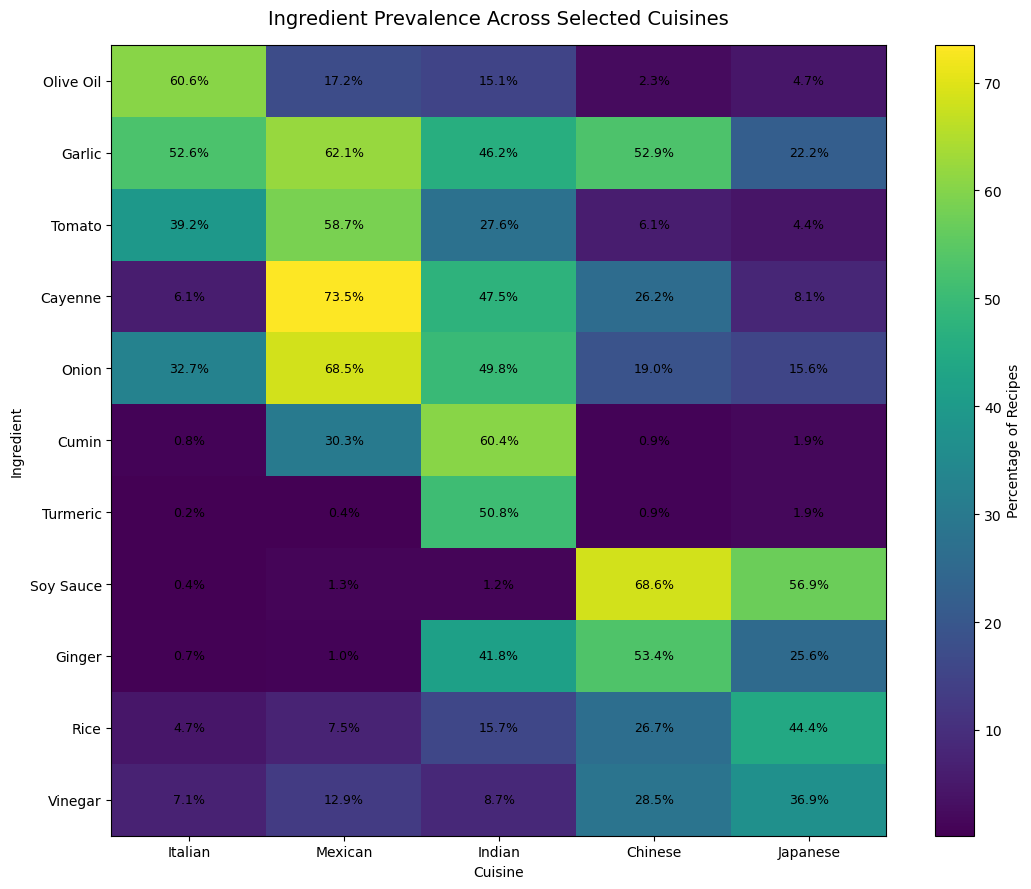

In [39]:
# Create an annotated heatmap
fig, ax = plt.subplots(figsize=(11, 9))

heatmap = ax.imshow(
    cuisine_comparison.T.values,
    aspect="auto"
)

# Cuisine labels on the x-axis
ax.set_xticks(range(len(selected_cuisines)))
ax.set_xticklabels(
    [cuisine.title() for cuisine in selected_cuisines]
)

# Ingredient labels on the y-axis
ax.set_yticks(range(len(comparison_ingredients)))
ax.set_yticklabels(
    [ingredient.replace("_", " ").title()
     for ingredient in comparison_ingredients]
)

# Add percentage labels inside each cell
for i in range(len(comparison_ingredients)):
    for j in range(len(selected_cuisines)):
        value = cuisine_comparison.T.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

# Titles and axis labels
ax.set_title(
    "Ingredient Prevalence Across Selected Cuisines",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Cuisine")
ax.set_ylabel("Ingredient")

# Add color scale
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Percentage of Recipes")

plt.tight_layout()

# Save portfolio-quality image
plt.savefig(
    images_dir / "cuisine_ingredient_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.7 Identifying Distinctive Cuisine Ingredients

High ingredient prevalence within a cuisine does not necessarily mean that an ingredient is distinctive. For example, an ingredient may occur frequently in one cuisine but also be widely used across many other cuisines.

To assess distinctiveness, an ingredient **lift score** is calculated by comparing its prevalence within a cuisine with its prevalence across the entire dataset.

A lift score greater than 1 indicates that the ingredient is more prevalent in that cuisine than in the dataset overall. To reduce the influence of very rare ingredients, only ingredients appearing in at least 10% of recipes within a cuisine are considered when identifying distinctive ingredients.

In [40]:
# Overall ingredient prevalence as proportions
overall_ingredient_prevalence = (
    recipes_clean[ingredient_columns].mean()
)

def distinctive_ingredients(cuisine_name, n=10, min_prevalence=0.10):
    # Ingredient prevalence within the selected cuisine
    cuisine_prevalence = cuisine_ingredient_prevalence.loc[cuisine_name]

    # Keep ingredients appearing in at least the specified proportion
    eligible = cuisine_prevalence[cuisine_prevalence >= min_prevalence]

    # Calculate lift relative to overall ingredient prevalence
    lift = (
        eligible /
        overall_ingredient_prevalence[eligible.index]
    )

    result = pd.DataFrame({
        "cuisine_prevalence_percent":
            (eligible * 100).round(2),
        "overall_prevalence_percent":
            (overall_ingredient_prevalence[eligible.index] * 100).round(2),
        "lift":
            lift.round(2)
    })

    return result.sort_values(
        "lift",
        ascending=False
    ).head(n)

In [41]:
distinctive_ingredients("italian")

,cuisine_prevalence_percent,overall_prevalence_percent,lift
mozzarella_cheese,12.71,2.25,5.66
parmesan_cheese,30.28,5.53,5.48
macaroni,28.31,5.43,5.22
basil,31.20,6.69,4.66
olive_oil,60.62,17.20,3.52
cheese,18.46,5.71,3.23
white_wine,11.88,3.84,3.09
oregano,16.15,5.54,2.92
parsley,24.03,9.67,2.48
tomato,39.23,17.28,2.27


In [42]:
for cuisine in selected_cuisines:
    print(f"\nMost distinctive ingredients in {cuisine.title()} cuisine:")
    display(distinctive_ingredients(cuisine, n=5))


Most distinctive ingredients in Italian cuisine:


,cuisine_prevalence_percent,overall_prevalence_percent,lift
mozzarella_cheese,12.71,2.25,5.66
parmesan_cheese,30.28,5.53,5.48
macaroni,28.31,5.43,5.22
basil,31.20,6.69,4.66
olive_oil,60.62,17.20,3.52



Most distinctive ingredients in Mexican cuisine:


,cuisine_prevalence_percent,overall_prevalence_percent,lift
avocado,10.42,1.15,9.06
cilantro,25.36,4.31,5.88
cumin,30.25,5.71,5.30
cayenne,73.51,14.38,5.11
lime_juice,14.06,2.82,4.99



Most distinctive ingredients in Indian cuisine:


,cuisine_prevalence_percent,overall_prevalence_percent,lift
cardamom,14.55,0.61,23.73
turmeric,50.84,2.25,22.60
fenugreek,28.76,1.61,17.87
coriander,47.83,2.87,16.66
yogurt,23.58,1.80,13.10



Most distinctive ingredients in Chinese cuisine:


,cuisine_prevalence_percent,overall_prevalence_percent,lift
peanut_oil,10.63,0.54,19.82
oyster,11.99,0.71,16.95
sesame_oil,39.59,2.95,13.42
shiitake,13.35,1.04,12.88
soy_sauce,68.55,6.62,10.36



Most distinctive ingredients in Japanese cuisine:


,cuisine_prevalence_percent,overall_prevalence_percent,lift
seaweed,19.69,0.37,52.56
wasabi,10.94,0.24,46.51
sake,27.81,1.18,23.48
barley,10.31,0.46,22.25
wine,20.00,1.79,11.19


### 6.8 Distinctive Ingredient Patterns Across Selected Cuisines

The lift scores of distinctive ingredients are compared across selected cuisines. Higher lift values indicate that an ingredient occurs disproportionately more often in a particular cuisine relative to its prevalence in the overall dataset.

In [43]:
# Collect the top 3 highest-lift ingredients from each selected cuisine
distinctive_comparison_ingredients = []

for cuisine in selected_cuisines:
    top_items = distinctive_ingredients(
        cuisine,
        n=3
    ).index

    for ingredient in top_items:
        if ingredient not in distinctive_comparison_ingredients:
            distinctive_comparison_ingredients.append(ingredient)

distinctive_comparison_ingredients

['mozzarella_cheese',
 'parmesan_cheese',
 'macaroni',
 'avocado',
 'cilantro',
 'cumin',
 'cardamom',
 'turmeric',
 'fenugreek',
 'peanut_oil',
 'oyster',
 'sesame_oil',
 'seaweed',
 'wasabi',
 'sake']

In [44]:
# Calculate lift values across the selected cuisines
lift_comparison = pd.DataFrame(
    index=selected_cuisines,
    columns=distinctive_comparison_ingredients,
    dtype=float
)

for cuisine in selected_cuisines:
    cuisine_prev = cuisine_ingredient_prevalence.loc[cuisine]

    lift_comparison.loc[cuisine] = (
        cuisine_prev[distinctive_comparison_ingredients]
        / overall_ingredient_prevalence[distinctive_comparison_ingredients]
    )

lift_comparison = lift_comparison.round(2)

lift_comparison

,mozzarella_cheese,parmesan_cheese,macaroni,avocado,cilantro,cumin,cardamom,turmeric,fenugreek,peanut_oil,oyster,sesame_oil,seaweed,wasabi,sake
italian,5.66,5.48,5.22,0.08,0.13,0.13,0.35,0.11,0.13,0.11,0.44,0.01,0.00,0.00,0.00
mexican,0.80,0.24,0.55,9.06,5.88,5.30,0.00,0.19,0.10,0.39,0.24,0.04,0.00,0.36,0.11
indian,0.00,0.12,0.15,0.00,6.60,10.58,23.73,22.60,17.87,1.87,0.00,0.40,0.00,0.00,0.00
chinese,0.00,0.08,0.33,0.00,2.68,0.16,0.00,0.40,0.56,19.82,16.95,13.42,0.00,0.00,7.45
japanese,0.00,0.06,0.06,4.08,0.73,0.33,0.00,0.83,1.16,2.91,0.88,4.56,52.56,46.51,23.48


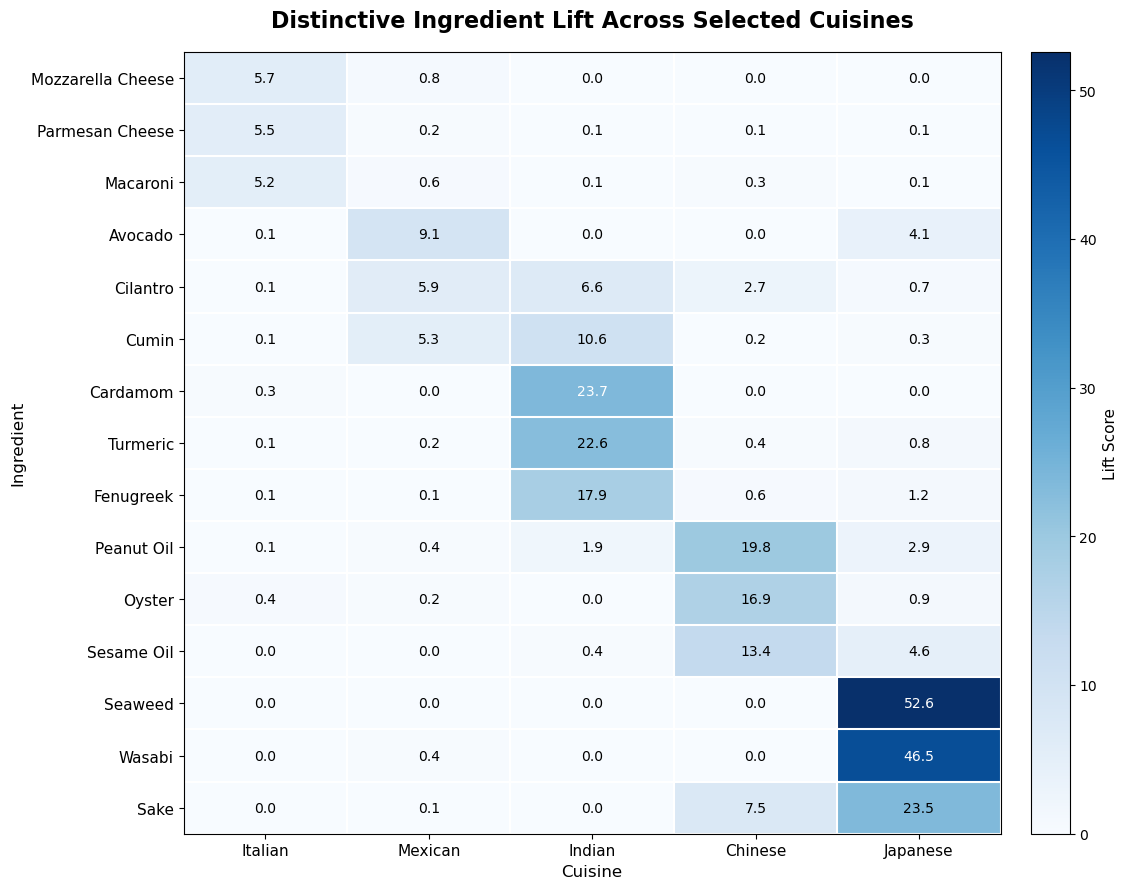

In [45]:
fig, ax = plt.subplots(figsize=(12, 9))

# Create heatmap with a cleaner sequential colour scale
heatmap = ax.imshow(
    lift_comparison.T.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=lift_comparison.max().max()
)

# X-axis labels
ax.set_xticks(range(len(selected_cuisines)))
ax.set_xticklabels(
    [cuisine.title() for cuisine in selected_cuisines],
    fontsize=11
)

# Y-axis labels
ax.set_yticks(range(len(distinctive_comparison_ingredients)))
ax.set_yticklabels(
    [
        ingredient.replace("_", " ").title()
        for ingredient in distinctive_comparison_ingredients
    ],
    fontsize=11
)

# Add cell values with dynamic text colour
max_value = lift_comparison.max().max()

for i in range(len(distinctive_comparison_ingredients)):
    for j in range(len(selected_cuisines)):
        value = lift_comparison.T.iloc[i, j]

        text_color = "white" if value > max_value * 0.45 else "black"

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

# Add subtle borders between cells
ax.set_xticks(
    np.arange(-0.5, len(selected_cuisines), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(distinctive_comparison_ingredients), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1.5
)

ax.tick_params(which="minor", bottom=False, left=False)

# Titles and labels
ax.set_title(
    "Distinctive Ingredient Lift Across Selected Cuisines",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Cuisine", fontsize=12)
ax.set_ylabel("Ingredient", fontsize=12)

# Colour bar
cbar = plt.colorbar(
    heatmap,
    ax=ax,
    pad=0.03
)

cbar.set_label(
    "Lift Score",
    fontsize=11
)

plt.tight_layout()

# Save improved version
plt.savefig(
    images_dir / "distinctive_ingredient_lift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.9 Exploratory Data Analysis Summary

The exploratory analysis revealed several important characteristics of the recipe dataset.

- The analytical dataset contains **57,403 recipes across 34 cuisine categories** after standardization and filtering.
- The target variable is highly imbalanced. **American cuisine accounts for approximately 70% of the recipes**, while many other cuisine categories represent relatively small proportions of the dataset.
- The most frequently occurring ingredients across all recipes are **egg, wheat, butter, onion, and garlic**.
- Many highly prevalent ingredients occur across several cuisines and therefore may have limited value on their own for distinguishing cuisine types.
- Cuisine-level analysis revealed clear differences in ingredient profiles. For example, Italian recipes show high prevalence of olive oil, garlic, tomato, basil, and parmesan cheese, while Indian recipes show stronger concentrations of cumin, turmeric, coriander, ginger, and fenugreek.
- Chinese and Japanese cuisines share some ingredients, particularly soy sauce, but differ considerably in the prevalence of other ingredients.
- Ingredient lift analysis identified ingredients that occur disproportionately more often in particular cuisines. Examples include mozzarella cheese and parmesan cheese for Italian cuisine, cardamom and turmeric for Indian cuisine, and seaweed and wasabi for Japanese cuisine.
- These patterns indicate that ingredient combinations contain meaningful information that may allow cuisine categories to be predicted using machine learning.

Because of the substantial class imbalance, model performance should not be evaluated using overall accuracy alone. Evaluation will therefore consider additional classification metrics and class-level performance.

## 7. Machine Learning Modelling

### 7.1 Preparing the Modelling Dataset

Exact duplicate observations were retained during exploratory analysis because identical ingredient profiles may represent separate recipes. However, retaining identical observations during model development could result in the same cuisine–ingredient profile appearing in both the training and test datasets.

To reduce the risk of information leakage and obtain a more conservative estimate of predictive performance, exact duplicate rows are removed from the modelling dataset. The cleaned dataset used for exploratory analysis remains unchanged.

In [46]:
# Create a separate dataset specifically for machine learning
model_data = recipes_clean.drop_duplicates().copy()

print("Recipes before modelling deduplication:", len(recipes_clean))
print("Recipes available for modelling:", len(model_data))
print("Exact duplicate rows removed for modelling:",
      len(recipes_clean) - len(model_data))

Recipes before modelling deduplication: 57403
Recipes available for modelling: 52635
Exact duplicate rows removed for modelling: 4768


In [47]:
# Predictor variables: 383 binary ingredient indicators
X = model_data.drop(columns="cuisine")

# Target variable: cuisine category
y = model_data["cuisine"]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of cuisine classes:", y.nunique())

Predictor matrix shape: (52635, 383)
Target vector shape: (52635,)
Number of cuisine classes: 34


### 7.2 Training and Test Sets

The modelling dataset is divided into training and test sets. An 80:20 split is used, with 80% of observations allocated to model training and 20% reserved for independent evaluation.

Because the cuisine classes are highly imbalanced, stratified sampling is used to preserve approximately the same cuisine distribution in both the training and test datasets. A fixed random state is specified to ensure that the split is reproducible.

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
print("Training predictor shape:", X_train.shape)
print("Test predictor shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print("\nNumber of cuisine classes in training set:",
      y_train.nunique())

print("Number of cuisine classes in test set:",
      y_test.nunique())

Training predictor shape: (42108, 383)
Test predictor shape: (10527, 383)
Training target shape: (42108,)
Test target shape: (10527,)

Number of cuisine classes in training set: 34
Number of cuisine classes in test set: 34


In [64]:
split_check = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True).mul(100),
    "Training Set (%)": y_train.value_counts(normalize=True).mul(100),
    "Test Set (%)": y_test.value_counts(normalize=True).mul(100)
}).round(2)

split_check.head(10)

,Full Dataset (%),Training Set (%),Test Set (%)
cuisine,,,
american,67.89,67.89,67.88
italian,6.00,6.00,6.00
mexican,4.46,4.46,4.46
french,2.31,2.31,2.31
asian,2.24,2.24,2.24
east_asian,1.77,1.77,1.78
korean,1.49,1.49,1.49
canadian,1.45,1.45,1.45
indian,1.13,1.13,1.13


### 7.3 Baseline Model

Before developing a machine learning classifier, a simple baseline model is established to provide a reference point for evaluating model performance.

Because American cuisine represents the majority of observations, a dummy classifier that always predicts the most frequent class is used as the baseline.

Given the substantial class imbalance, the baseline is evaluated using overall accuracy, balanced accuracy, and macro-averaged F1-score. These metrics provide a more complete view of performance than accuracy alone.

In [65]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Create majority-class baseline model
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Train baseline model
baseline_model.fit(X_train, y_train)

# Generate predictions
baseline_predictions = baseline_model.predict(X_test)

In [66]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

baseline_macro_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro",
    zero_division=0
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy:.4f}")
print(f"Baseline Macro F1-score: {baseline_macro_f1:.4f}")

Baseline Accuracy: 0.6788
Baseline Balanced Accuracy: 0.0294
Baseline Macro F1-score: 0.0238


In [67]:
print(
    "Baseline predicted cuisine:",
    baseline_model.classes_[
        baseline_model.class_prior_.argmax()
    ]
)

Baseline predicted cuisine: american


### 7.4 Decision Tree Classifier

A Decision Tree classifier is used as the first supervised machine learning model. Decision trees are suitable for this problem because they can learn non-linear combinations of binary ingredient features and provide an interpretable representation of the classification process.

A maximum tree depth is specified to limit excessive model complexity, while a fixed random state ensures reproducibility.

In [68]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree classifier
decision_tree = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Generate predictions for the test set
tree_predictions = decision_tree.predict(X_test)

In [59]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_balanced_accuracy = balanced_accuracy_score(
    y_test,
    tree_predictions
)

tree_macro_f1 = f1_score(
    y_test,
    tree_predictions,
    average="macro",
    zero_division=0
)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print(f"Decision Tree Balanced Accuracy: {tree_balanced_accuracy:.4f}")
print(f"Decision Tree Macro F1-score: {tree_macro_f1:.4f}")

Decision Tree Accuracy: 0.6876
Decision Tree Balanced Accuracy: 0.0834
Decision Tree Macro F1-score: 0.0932


In [69]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_balanced_accuracy,
        baseline_macro_f1
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_balanced_accuracy,
        tree_macro_f1
    ]
})

model_comparison

,Metric,Baseline,Decision Tree
0,Accuracy,0.678826,0.687565
1,Balanced Accuracy,0.029412,0.083425
2,Macro F1-score,0.023785,0.093217


### 7.5 Initial Decision Tree Performance

The Decision Tree achieved an overall accuracy of approximately **68.76%**, compared with **67.88%** for the majority-class baseline.

Although the improvement in overall accuracy is modest, the Decision Tree performs substantially better on metrics that account for class imbalance. Balanced accuracy increased from approximately **2.94% to 8.34%**, while the macro F1-score increased from approximately **2.38% to 9.32%**.

These results indicate that the Decision Tree is learning patterns associated with some minority cuisine categories rather than predicting only the dominant American class. However, the relatively low balanced accuracy and macro F1-score suggest that performance remains uneven across the 34 cuisine categories.

A class-level evaluation is therefore required to determine which cuisines are being classified successfully and which remain difficult for the model to distinguish.

In [70]:
from sklearn.metrics import classification_report

tree_report = classification_report(
    y_test,
    tree_predictions,
    output_dict=True,
    zero_division=0
)

tree_report_df = pd.DataFrame(tree_report).T

tree_report_df

,precision,recall,f1-score,support
african,0.090909,0.043478,0.058824,23.000000
american,0.744732,0.944724,0.832891,7146.000000
asian,0.193182,0.144068,0.165049,236.000000
cajun_creole,0.000000,0.000000,0.000000,29.000000
canadian,0.000000,0.000000,0.000000,153.000000
caribbean,0.000000,0.000000,0.000000,36.000000
central_southamerican,0.142857,0.020833,0.036364,48.000000
chinese,0.125000,0.045455,0.066667,88.000000
east_asian,0.271028,0.310160,0.289277,187.000000
eastern-europe,0.000000,0.000000,0.000000,46.000000


In [71]:
# Extract class-level performance only
class_performance = tree_report_df.loc[
    decision_tree.classes_,
    ["precision", "recall", "f1-score", "support"]
]

# Sort cuisines by F1-score
class_performance_sorted = class_performance.sort_values(
    "f1-score",
    ascending=False
)

class_performance_sorted

,precision,recall,f1-score,support
american,0.744732,0.944724,0.832891,7146.0
mexican,0.562914,0.362473,0.440986,469.0
indian,0.515625,0.277311,0.360656,119.0
italian,0.441441,0.232595,0.304663,632.0
east_asian,0.271028,0.310160,0.289277,187.0
thai,0.214286,0.157895,0.181818,57.0
asian,0.193182,0.144068,0.165049,236.0
japanese,0.150000,0.095238,0.116505,63.0
korean,0.107143,0.057325,0.074689,157.0
chinese,0.125000,0.045455,0.066667,88.0


### 7.6 Class-Level Performance

The class-level evaluation reveals substantial variation in model performance across cuisines.

The Decision Tree performs strongest for the dominant American cuisine class, with an F1-score of approximately **0.83** and recall of approximately **0.94**. The model also shows some ability to distinguish Mexican, Indian, Italian, and East Asian recipes.

However, performance declines considerably for many smaller cuisine categories. Several classes record zero recall and zero F1-score, indicating that the model does not correctly identify any observations from those cuisines in the test dataset.

These findings confirm that overall accuracy substantially overstates the model's ability to classify recipes across all cuisine categories. The next step therefore examines the model's confusion matrix to determine which cuisines are being confused with one another.

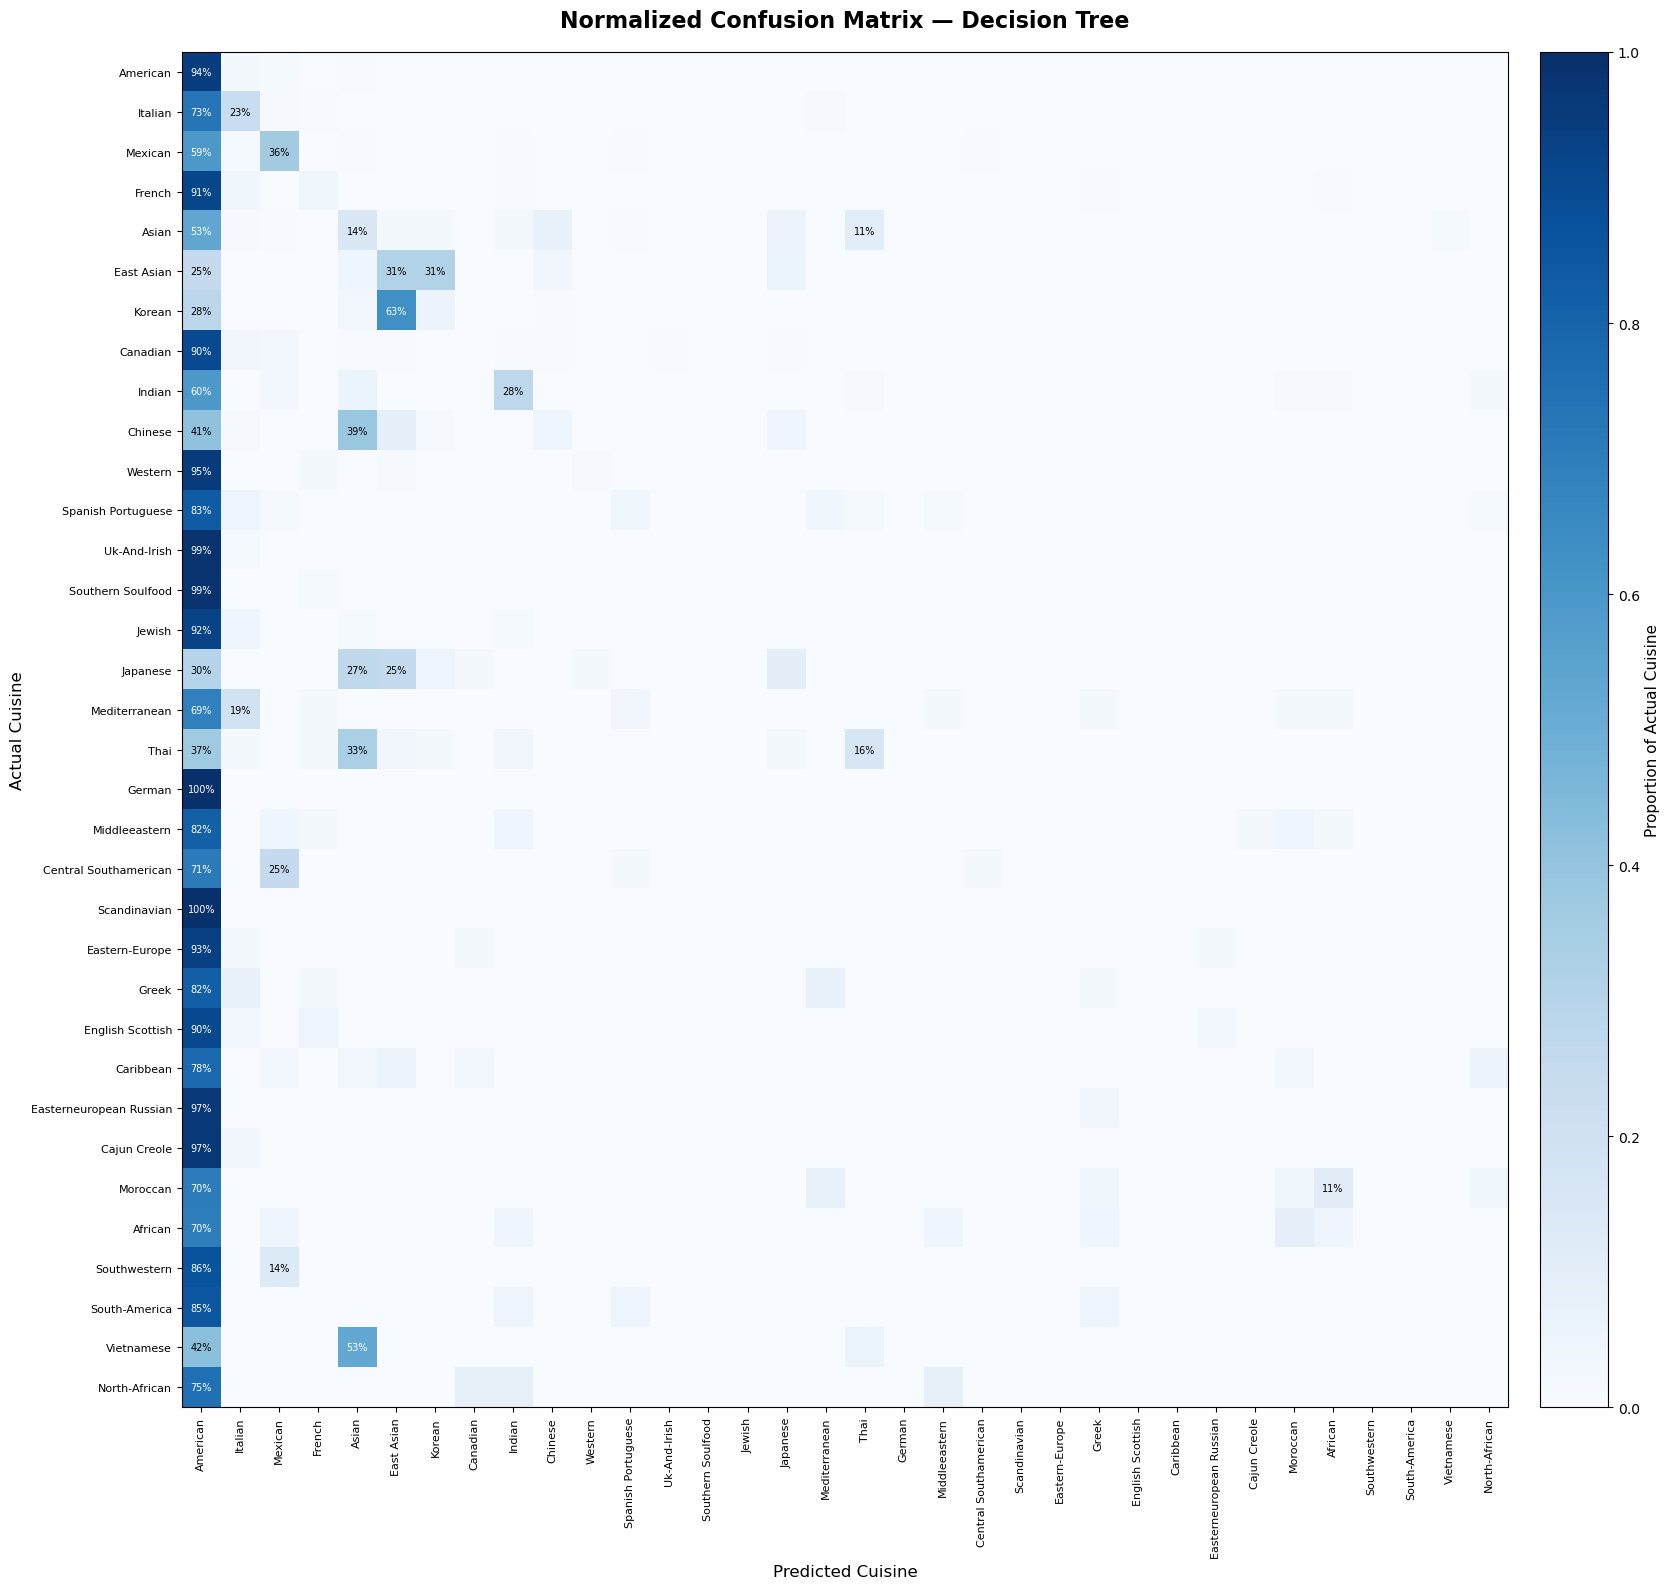

In [72]:
from sklearn.metrics import confusion_matrix

# Order cuisine classes by frequency in the test set
class_labels = y_test.value_counts().index.tolist()

# Row-normalized confusion matrix
cm_normalized = confusion_matrix(
    y_test,
    tree_predictions,
    labels=class_labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 16))

im = ax.imshow(
    cm_normalized,
    cmap="Blues",
    aspect="auto"
)

ax.set_xticks(range(len(class_labels)))
ax.set_xticklabels(
    [label.replace("_", " ").title() for label in class_labels],
    rotation=90,
    fontsize=8
)

ax.set_yticks(range(len(class_labels)))
ax.set_yticklabels(
    [label.replace("_", " ").title() for label in class_labels],
    fontsize=8
)

# Only annotate substantial confusion rates to avoid clutter
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        value = cm_normalized[i, j]

        if value >= 0.10:
            ax.text(
                j,
                i,
                f"{value * 100:.0f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if value > 0.50 else "black"
            )

ax.set_title(
    "Normalized Confusion Matrix — Decision Tree",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Predicted Cuisine", fontsize=12)
ax.set_ylabel("Actual Cuisine", fontsize=12)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Proportion of Actual Cuisine", fontsize=11)

plt.tight_layout()

plt.savefig(
    images_dir / "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.7 Focused Confusion Matrix

Because the complete 34-class confusion matrix is visually dense, a focused confusion matrix is presented for the ten cuisine categories with the largest number of test observations. Predictions outside these ten categories are grouped into an `Other` category.

This provides a clearer view of the model's major classification and misclassification patterns while retaining the complete confusion matrix above for reference.

In [73]:
# Select the 10 largest cuisine classes in the test set
top_10_classes = y_test.value_counts().head(10).index.tolist()

# Create a dataframe of actual and predicted values
focused_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": tree_predictions
})

# Keep observations whose actual cuisine is among the top 10
focused_results = focused_results[
    focused_results["Actual"].isin(top_10_classes)
].copy()

# Group predictions outside the top 10 as "other"
focused_results["Predicted_Group"] = focused_results["Predicted"].where(
    focused_results["Predicted"].isin(top_10_classes),
    "other"
)

# Create row-normalized confusion table
focused_cm = pd.crosstab(
    focused_results["Actual"],
    focused_results["Predicted_Group"],
    normalize="index"
)

# Ensure consistent row and column order
column_order = top_10_classes + ["other"]

focused_cm = (
    focused_cm
    .reindex(index=top_10_classes, columns=column_order, fill_value=0)
)

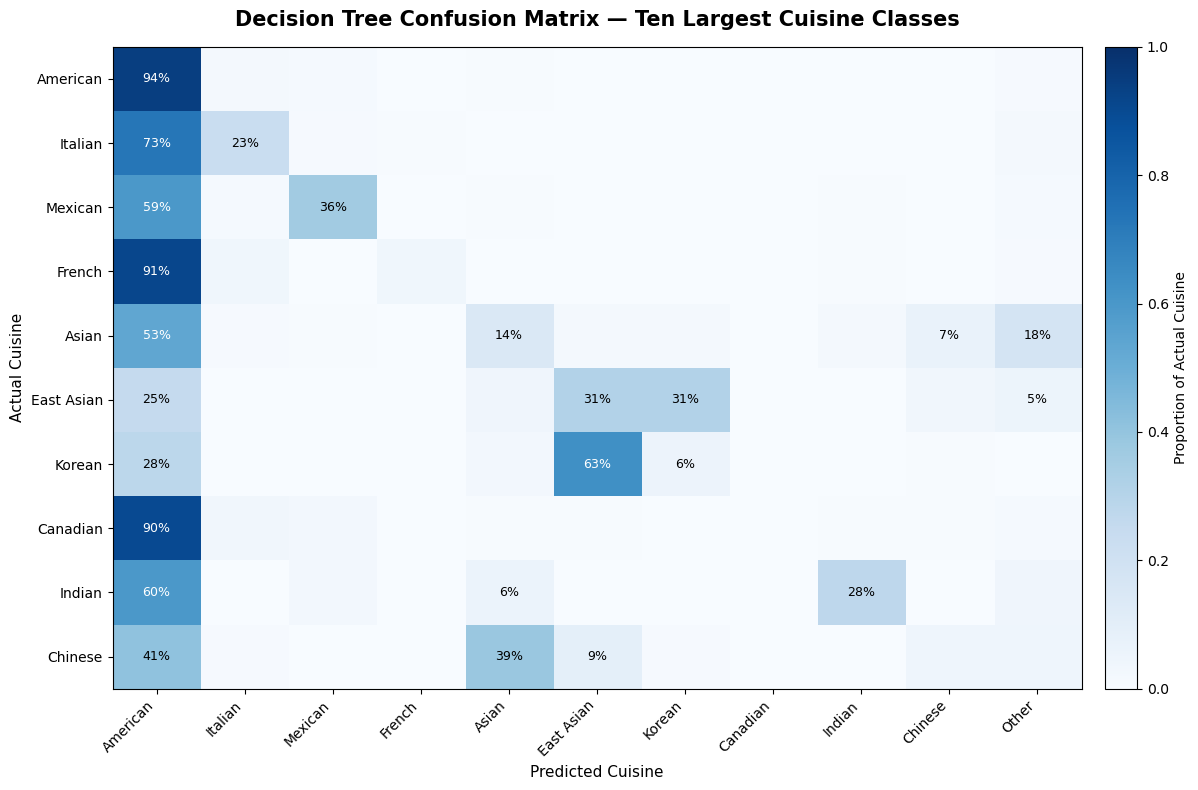

In [74]:
fig, ax = plt.subplots(figsize=(13, 8))

im = ax.imshow(
    focused_cm.values,
    cmap="Blues",
    aspect="auto",
    vmin=0,
    vmax=1
)

# Labels
ax.set_xticks(range(len(column_order)))
ax.set_xticklabels(
    [x.replace("_", " ").title() for x in column_order],
    rotation=45,
    ha="right",
    fontsize=10
)

ax.set_yticks(range(len(top_10_classes)))
ax.set_yticklabels(
    [x.replace("_", " ").title() for x in top_10_classes],
    fontsize=10
)

# Percentage annotations
for i in range(len(top_10_classes)):
    for j in range(len(column_order)):
        value = focused_cm.iloc[i, j]

        if value >= 0.05:
            ax.text(
                j,
                i,
                f"{value * 100:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if value > 0.50 else "black"
            )

ax.set_title(
    "Decision Tree Confusion Matrix — Ten Largest Cuisine Classes",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Cuisine", fontsize=11)
ax.set_ylabel("Actual Cuisine", fontsize=11)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Proportion of Actual Cuisine")

plt.tight_layout()

plt.savefig(
    images_dir / "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 7.8 Addressing Class Imbalance

The initial Decision Tree showed substantially better performance than the majority-class baseline on balanced accuracy and macro F1-score. However, class-level evaluation indicated that the model remained strongly influenced by the dominant American cuisine category.

To address this imbalance, a second Decision Tree is trained using class weights. Setting `class_weight="balanced"` automatically assigns greater importance to underrepresented cuisine categories during model training while reducing the relative influence of the majority class.

The same maximum tree depth is retained so that the effect of class weighting can be compared directly with the original Decision Tree.

In [75]:
# Create a class-balanced Decision Tree
balanced_tree = DecisionTreeClassifier(
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

# Train the model
balanced_tree.fit(X_train, y_train)

# Generate test-set predictions
balanced_tree_predictions = balanced_tree.predict(X_test)

In [76]:
balanced_tree_accuracy = accuracy_score(
    y_test,
    balanced_tree_predictions
)

balanced_tree_balanced_accuracy = balanced_accuracy_score(
    y_test,
    balanced_tree_predictions
)

balanced_tree_macro_f1 = f1_score(
    y_test,
    balanced_tree_predictions,
    average="macro",
    zero_division=0
)

print(f"Balanced Tree Accuracy: {balanced_tree_accuracy:.4f}")
print(
    f"Balanced Tree Balanced Accuracy: "
    f"{balanced_tree_balanced_accuracy:.4f}"
)
print(f"Balanced Tree Macro F1-score: {balanced_tree_macro_f1:.4f}")

Balanced Tree Accuracy: 0.0901
Balanced Tree Balanced Accuracy: 0.1751
Balanced Tree Macro F1-score: 0.1027


In [77]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_balanced_accuracy,
        baseline_macro_f1
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_balanced_accuracy,
        tree_macro_f1
    ],
    "Balanced Decision Tree": [
        balanced_tree_accuracy,
        balanced_tree_balanced_accuracy,
        balanced_tree_macro_f1
    ]
})

model_comparison

,Metric,Baseline,Decision Tree,Balanced Decision Tree
0,Accuracy,0.678826,0.687565,0.090149
1,Balanced Accuracy,0.029412,0.083425,0.175122
2,Macro F1-score,0.023785,0.093217,0.102673


### 7.9 Effect of Class Weighting

Applying balanced class weights substantially changed the behaviour of the Decision Tree.

The balanced Decision Tree increased balanced accuracy from approximately **8.34% to 17.51%**, indicating improved attention to minority cuisine categories. Macro F1-score also increased slightly from approximately **9.32% to 10.27%**.

However, overall accuracy declined sharply from approximately **68.76% to 9.01%**. This suggests that class weighting overcorrected for the dominance of the American cuisine class and substantially reduced the model's ability to classify the dataset accurately overall.

The experiment demonstrates that addressing class imbalance involves a trade-off between majority-class performance and minority-class recognition. A different modelling approach may provide a better balance between these objectives.

### 7.10 Random Forest Classifier

A Random Forest classifier is evaluated as an ensemble alternative to the single Decision Tree. Random Forest combines predictions from multiple decision trees, which can improve generalization and reduce the instability associated with an individual tree.

The initial Random Forest model is trained without class weighting so that its performance can be compared directly with the baseline and Decision Tree models.

In [78]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

In [79]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    rf_predictions
)

rf_macro_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Balanced Accuracy: {rf_balanced_accuracy:.4f}")
print(f"Random Forest Macro F1-score: {rf_macro_f1:.4f}")

Random Forest Accuracy: 0.6900
Random Forest Balanced Accuracy: 0.0860
Random Forest Macro F1-score: 0.0962


### 7.11 Random Forest Performance

The Random Forest classifier achieved an overall accuracy of approximately **69.00%**, slightly higher than the single Decision Tree at **68.76%**.

Balanced accuracy increased modestly from approximately **8.34% for the Decision Tree to 8.60% for the Random Forest**, while the macro F1-score increased from approximately **9.32% to 9.62%**.

These results indicate that combining multiple decision trees produces a small improvement in predictive performance, but the model continues to struggle with minority cuisine categories. The relatively small gains also suggest that the severe class imbalance and overlap in ingredient patterns remain important challenges.

In [80]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Balanced Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        tree_accuracy,
        balanced_tree_accuracy,
        rf_accuracy
    ],
    "Balanced Accuracy": [
        baseline_balanced_accuracy,
        tree_balanced_accuracy,
        balanced_tree_balanced_accuracy,
        rf_balanced_accuracy
    ],
    "Macro F1-score": [
        baseline_macro_f1,
        tree_macro_f1,
        balanced_tree_macro_f1,
        rf_macro_f1
    ]
}).round(4)

model_comparison

,Model,Accuracy,Balanced Accuracy,Macro F1-score
0,Baseline,0.6788,0.0294,0.0238
1,Decision Tree,0.6876,0.0834,0.0932
2,Balanced Decision Tree,0.0901,0.1751,0.1027
3,Random Forest,0.6900,0.0860,0.0962


### 7.12 Logistic Regression Classifier

Logistic Regression is evaluated as an alternative multiclass classification approach. Unlike the tree-based models, Logistic Regression estimates the relationship between each ingredient and the probability of a recipe belonging to each cuisine category.

Because all predictor variables are binary indicators measured on the same scale, additional feature scaling is not required for this initial model.

In [81]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    random_state=42,
    n_jobs=-1
)

# Train the model
logistic_model.fit(X_train, y_train)

# Generate predictions
logistic_predictions = logistic_model.predict(X_test)

C:\Users\mikem\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [82]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_balanced_accuracy = balanced_accuracy_score(
    y_test,
    logistic_predictions
)

logistic_macro_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(
    f"Logistic Regression Balanced Accuracy: "
    f"{logistic_balanced_accuracy:.4f}"
)
print(
    f"Logistic Regression Macro F1-score: "
    f"{logistic_macro_f1:.4f}"
)

Logistic Regression Accuracy: 0.7246
Logistic Regression Balanced Accuracy: 0.1622
Logistic Regression Macro F1-score: 0.1936


### 7.13 Logistic Regression Performance

The Logistic Regression classifier produced the strongest overall performance among the models evaluated so far.

The model achieved an overall accuracy of approximately **72.46%**, compared with 69.00% for the Random Forest and 68.76% for the original Decision Tree.

More importantly, balanced accuracy increased to approximately **16.22%**, while the macro F1-score increased substantially to approximately **19.36%**. This indicates that Logistic Regression provides a better balance between overall predictive accuracy and performance across the different cuisine categories.

The improvement suggests that the relationship between individual ingredient indicators and cuisine categories can be effectively captured using a multiclass linear classification approach. Nevertheless, the relatively modest balanced accuracy indicates that class imbalance remains an important modelling challenge.

### 7.14 Class-Balanced Logistic Regression

To further address the imbalance among cuisine categories, a second Logistic Regression model is trained using balanced class weights. This allows the model to assign greater importance to underrepresented cuisines during training.

The purpose of this experiment is to determine whether minority-class recognition can be improved without experiencing the severe reduction in overall accuracy observed with the class-balanced Decision Tree.

In [87]:
from sklearn.linear_model import LogisticRegression

balanced_logistic_model = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

balanced_logistic_model.fit(X_train, y_train)

balanced_logistic_predictions = balanced_logistic_model.predict(X_test)

print("Balanced Logistic Regression training completed.")

Balanced Logistic Regression training completed.


In [88]:
balanced_logistic_accuracy = accuracy_score(
    y_test,
    balanced_logistic_predictions
)

balanced_logistic_balanced_accuracy = balanced_accuracy_score(
    y_test,
    balanced_logistic_predictions
)

balanced_logistic_macro_f1 = f1_score(
    y_test,
    balanced_logistic_predictions,
    average="macro",
    zero_division=0
)

print(
    f"Balanced Logistic Regression Accuracy: "
    f"{balanced_logistic_accuracy:.4f}"
)

print(
    f"Balanced Logistic Regression Balanced Accuracy: "
    f"{balanced_logistic_balanced_accuracy:.4f}"
)

print(
    f"Balanced Logistic Regression Macro F1-score: "
    f"{balanced_logistic_macro_f1:.4f}"
)

Balanced Logistic Regression Accuracy: 0.2032
Balanced Logistic Regression Balanced Accuracy: 0.3312
Balanced Logistic Regression Macro F1-score: 0.1717


### 7.15 Effect of Class Weighting on Logistic Regression

Applying balanced class weights substantially changed the behaviour of the Logistic Regression classifier.

Balanced accuracy increased from approximately **16.22% to 33.12%**, indicating a substantial improvement in the model's ability to recognize underrepresented cuisine categories.

However, this improvement came at a considerable cost. Overall accuracy declined from approximately **72.46% to 20.32%**, while the macro F1-score decreased from approximately **19.36% to 17.17%**.

The results therefore demonstrate a clear trade-off between majority-class predictive accuracy and minority-class recognition. Although the class-balanced model performs considerably better across cuisine classes in terms of balanced accuracy, the ordinary Logistic Regression provides a more practical overall balance between accuracy and class-level performance and is therefore retained for further evaluation.

In [89]:
from sklearn.metrics import classification_report

logistic_report = classification_report(
    y_test,
    logistic_predictions,
    output_dict=True,
    zero_division=0
)

logistic_report_df = (
    pd.DataFrame(logistic_report)
    .transpose()
    .drop(index=["accuracy", "macro avg", "weighted avg"])
    .sort_values("f1-score", ascending=False)
)

logistic_report_df

,precision,recall,f1-score,support
american,0.768139,0.946683,0.848116,7146.0
indian,0.731707,0.504202,0.597015,119.0
mexican,0.646438,0.522388,0.577830,469.0
east_asian,0.431579,0.438503,0.435013,187.0
asian,0.456410,0.377119,0.412993,236.0
italian,0.506297,0.318038,0.390671,632.0
thai,0.363636,0.280702,0.316832,57.0
japanese,0.369565,0.269841,0.311927,63.0
korean,0.382353,0.248408,0.301158,157.0
chinese,0.388889,0.238636,0.295775,88.0


### 7.16 Cuisine-Level Performance of Logistic Regression

Cuisine-level evaluation reveals substantial variation in model performance.

The strongest classification performance was observed for **American cuisine (F1 = 0.848)**, followed by **Indian (F1 = 0.597)** and **Mexican (F1 = 0.578)**. East Asian, Asian, and Italian cuisines also achieved moderate classification performance.

American cuisine achieved a recall of approximately **94.67%**, indicating that the model correctly identified most American recipes. However, its lower precision of approximately **76.81%** suggests that recipes belonging to other cuisines were also frequently classified as American. This reflects the strong class imbalance in the dataset.

Performance was substantially weaker for many less-represented cuisine categories. Several cuisines, including North African, South American, Southwestern, Canadian, Eastern European/Russian, and English/Scottish, recorded an F1-score of zero, indicating that the model produced no correct classifications for these categories in the test set.

Some minority cuisines also exhibited high precision but very low recall. For example, Cajun/Creole achieved a precision of 1.00 but recall of only approximately 6.90%. This demonstrates why precision, recall, and F1-score should be interpreted together rather than relying on a single performance measure.

Overall, the results confirm that Logistic Regression provides substantially better multiclass performance than the earlier tree-based models, but the severe class imbalance continues to limit reliable classification of many minority cuisine categories.

In [91]:
# Prepare data for the focused Logistic Regression confusion matrix

# Identify the 10 most represented cuisines in the test set
top_10_cuisines = y_test.value_counts().head(10).index.tolist()

# Keep observations whose actual cuisine is among the top 10
top10_mask = y_test.isin(top_10_cuisines)

y_test_top10 = y_test[top10_mask]

y_pred_top10 = pd.Series(
    logistic_predictions,
    index=y_test.index
)[top10_mask].copy()

# Group predictions outside the top 10 as "other"
y_pred_top10 = y_pred_top10.where(
    y_pred_top10.isin(top_10_cuisines),
    "other"
)

# Create row-normalized confusion matrix
focused_cm = pd.crosstab(
    y_test_top10,
    y_pred_top10,
    normalize="index"
)

# Ensure consistent ordering
focused_cm = focused_cm.reindex(
    index=top_10_cuisines,
    columns=top_10_cuisines + ["other"],
    fill_value=0
)

# Convert proportions to percentages
focused_cm_percent = focused_cm * 100

print("Focused confusion matrix prepared successfully.")
print("Shape:", focused_cm_percent.shape)

Focused confusion matrix prepared successfully.
Shape: (10, 11)


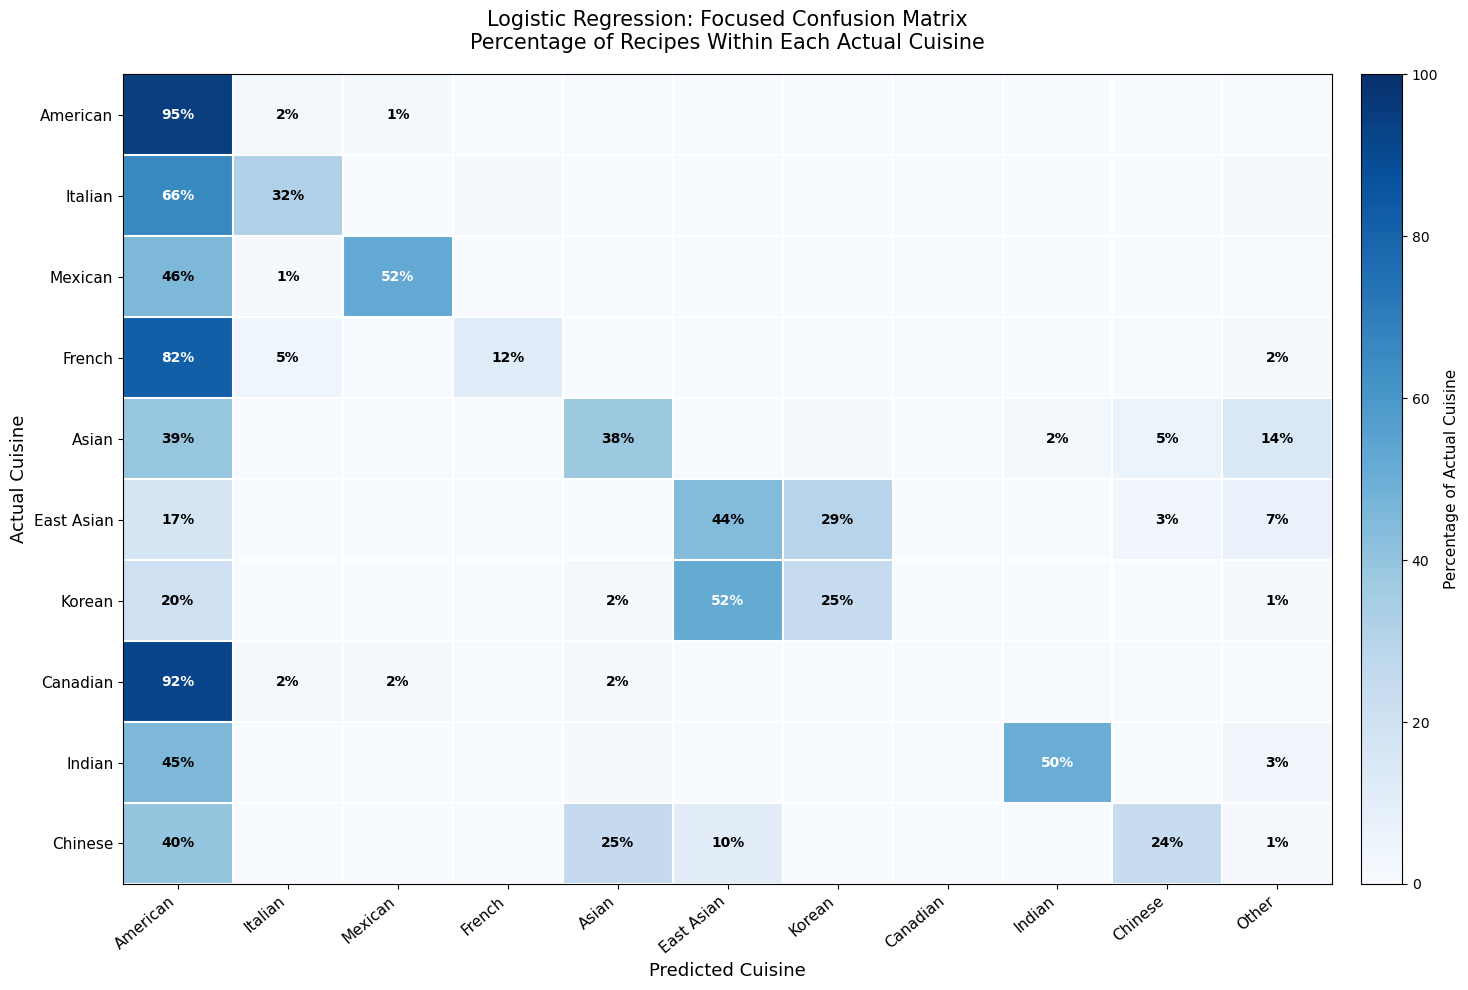

In [92]:
# Improve display labels
display_rows = [
    label.replace("_", " ").title()
    for label in focused_cm_percent.index
]

display_cols = [
    label.replace("_", " ").title()
    for label in focused_cm_percent.columns
]

# Create larger figure
fig, ax = plt.subplots(figsize=(16, 10))

im = ax.imshow(
    focused_cm_percent.values,
    cmap="Blues",
    vmin=0,
    vmax=100,
    aspect="auto"
)

# Axis labels
ax.set_xticks(range(len(display_cols)))
ax.set_xticklabels(
    display_cols,
    rotation=40,
    ha="right",
    fontsize=11
)

ax.set_yticks(range(len(display_rows)))
ax.set_yticklabels(
    display_rows,
    fontsize=11
)

ax.set_xlabel("Predicted Cuisine", fontsize=13)
ax.set_ylabel("Actual Cuisine", fontsize=13)

ax.set_title(
    "Logistic Regression: Focused Confusion Matrix\n"
    "Percentage of Recipes Within Each Actual Cuisine",
    fontsize=15,
    pad=18
)

# Add percentage annotations
for i in range(focused_cm_percent.shape[0]):
    for j in range(focused_cm_percent.shape[1]):

        value = focused_cm_percent.iloc[i, j]

        if value >= 1:
            text_color = "white" if value >= 50 else "black"

            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                fontweight="bold"
            )

# Add visible cell boundaries
ax.set_xticks(
    np.arange(-0.5, focused_cm_percent.shape[1], 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, focused_cm_percent.shape[0], 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=1.5
)

ax.tick_params(which="minor", bottom=False, left=False)

# Colour bar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(
    "Percentage of Actual Cuisine",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    images_dir / "logistic_regression_confusion_matrix_focused.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.17 Interpretation of the Logistic Regression Confusion Matrix

The focused confusion matrix confirms that the Logistic Regression model performs very differently across cuisine categories.

American cuisine is classified very strongly, with approximately **95% of American recipes correctly identified**. Mexican and Indian cuisines also show comparatively stronger classification, with approximately **52% and 50%** of their recipes correctly classified, respectively.

However, several cuisines are frequently misclassified as American. Approximately **66% of Italian recipes**, **82% of French recipes**, and **92% of Canadian recipes** are predicted as American. This reflects the strong dominance of the American class in the training data and indicates that the model has a tendency to favour the majority cuisine when ingredient patterns are not sufficiently distinctive.

The matrix also reveals overlap among related cuisine categories. For example, approximately **52% of Korean recipes are classified as East Asian**, while a substantial proportion of Chinese recipes are classified as either Asian or East Asian. This suggests that some cuisine categories share similar ingredient profiles, making them difficult to separate using binary ingredient indicators alone.

Overall, the confusion matrix reinforces the conclusion that Logistic Regression improves multiclass prediction relative to the earlier tree-based models, but strong class imbalance and overlapping ingredient patterns remain important sources of classification error.

In [93]:
# Create a coefficient table
logistic_coefficients = pd.DataFrame(
    logistic_model.coef_,
    index=logistic_model.classes_,
    columns=X_train.columns
)

def top_predictive_ingredients(cuisine_name, n=10):
    return (
        logistic_coefficients
        .loc[cuisine_name]
        .sort_values(ascending=False)
        .head(n)
        .round(3)
    )

selected_cuisines = [
    "italian",
    "mexican",
    "indian",
    "chinese",
    "japanese"
]

for cuisine in selected_cuisines:
    print(f"\nTop predictive ingredients for {cuisine.title()}:")
    print(top_predictive_ingredients(cuisine))


Top predictive ingredients for Italian:
parmesan_cheese    1.899
grape_brandy       1.830
truffle            1.673
blue_cheese        1.449
romano_cheese      1.447
lovage             1.438
rapeseed           1.383
hazelnut           1.306
tamarind           1.277
olive_oil          1.275
Name: italian, dtype: float64

Top predictive ingredients for Mexican:
tequila           2.366
cheddar_cheese    1.947
cayenne           1.763
prickly_pear      1.594
avocado           1.499
corn              1.181
cream_cheese      1.161
oregano           1.157
lime              1.138
cheese            1.077
Name: mexican, dtype: float64

Top predictive ingredients for Indian:
cardamom                   2.364
yogurt                     2.185
turmeric                   1.723
cashew                     1.623
mango                      1.528
tamarind                   1.491
ginger                     1.261
cumin                      1.232
whole_grain_wheat_flour    1.218
cilantro                   1.20

### 7.18 Interpretation of Logistic Regression Coefficients

The Logistic Regression coefficients provide insight into the ingredient patterns used by the model to distinguish among cuisine categories. Larger positive coefficients indicate ingredients that contribute more strongly toward predicting a particular cuisine, after accounting for the other ingredient indicators.

Several of the model's strongest predictors are consistent with the patterns identified during exploratory data analysis. For example, Italian cuisine is strongly associated with parmesan cheese and olive oil; Mexican cuisine with tequila, cayenne, avocado and corn; Indian cuisine with cardamom, turmeric, cumin and cilantro; Chinese cuisine with soy sauce, star anise, peanut oil and sesame oil; and Japanese cuisine with seaweed, sake, soy sauce and kelp.

The coefficient analysis also highlights ingredients that may not necessarily be among the most frequently occurring ingredients within a cuisine but are highly useful for distinguishing that cuisine from others. For example, grape brandy receives a relatively large positive coefficient for Italian cuisine, while prickly pear is strongly associated with Mexican cuisine.

These results demonstrate an important distinction between **ingredient prevalence** and **predictive importance**. Prevalence measures how commonly an ingredient occurs within a cuisine, whereas the Logistic Regression coefficient reflects how strongly the presence of that ingredient helps distinguish the cuisine from competing categories.

Overall, the coefficient patterns provide additional evidence that the model is learning meaningful cuisine-specific ingredient relationships rather than relying exclusively on the most common ingredients in the dataset.

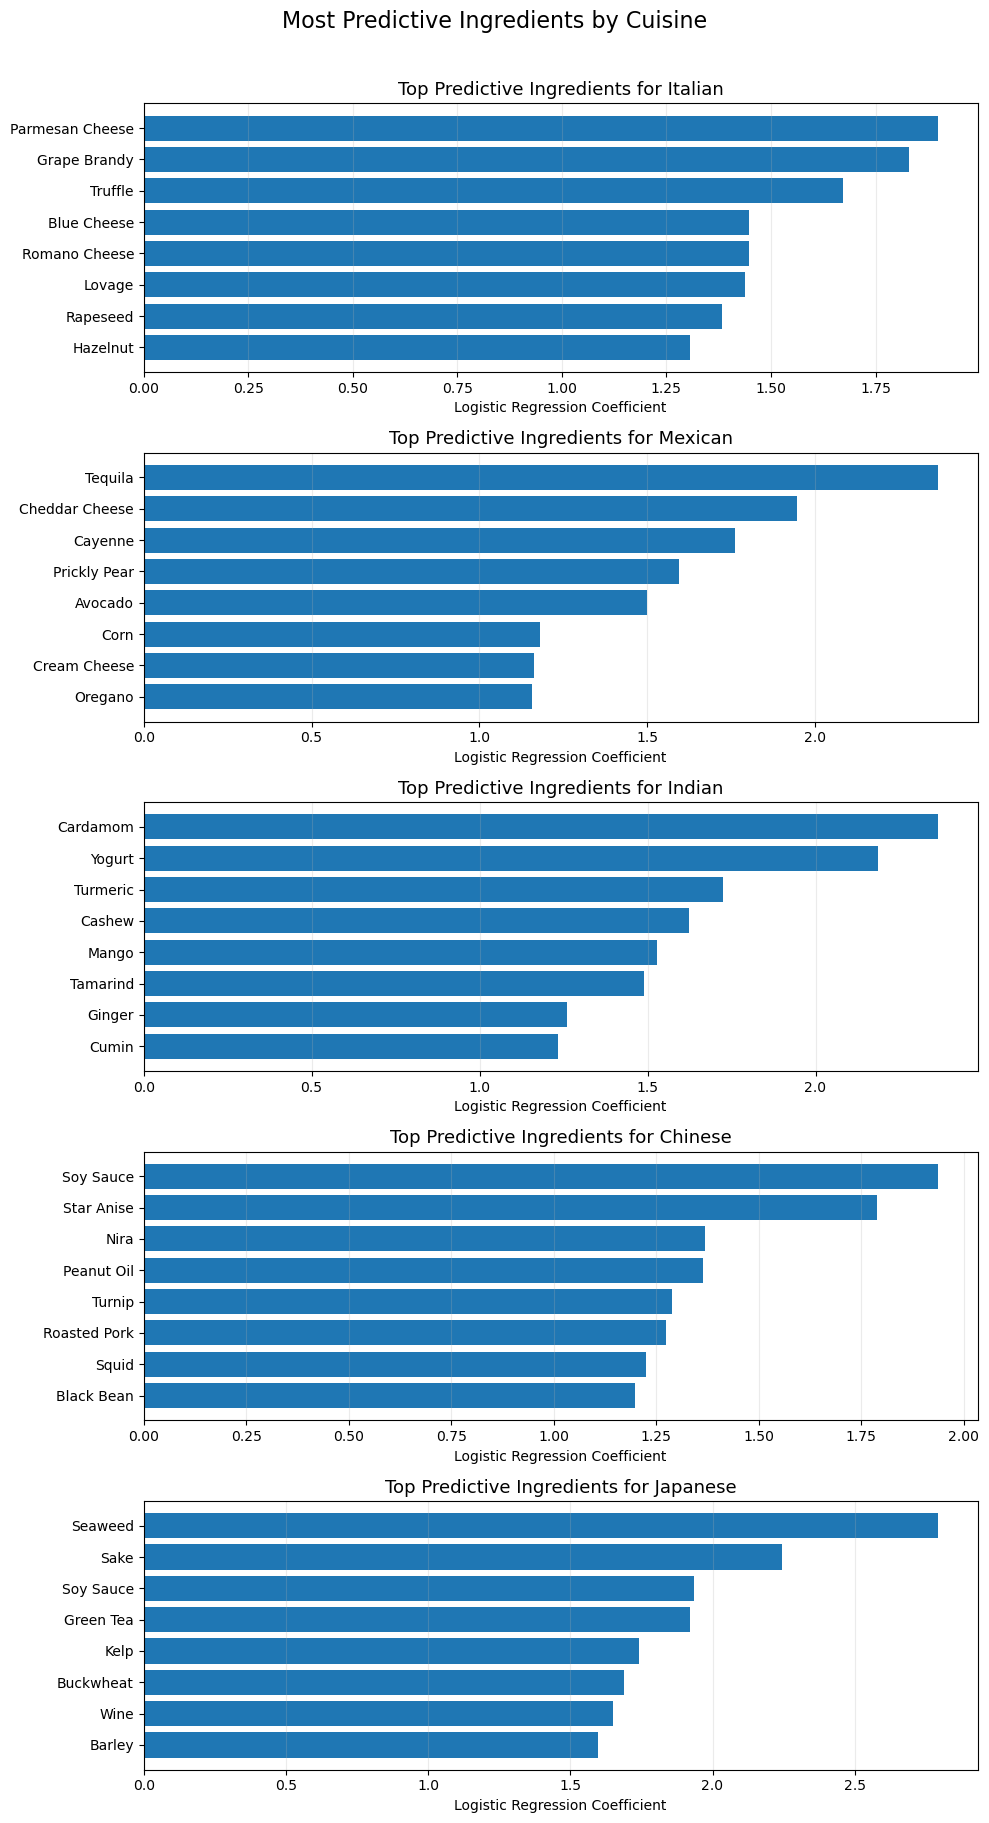

In [94]:
selected_cuisines = [
    "italian",
    "mexican",
    "indian",
    "chinese",
    "japanese"
]

top_n = 8

fig, axes = plt.subplots(
    nrows=len(selected_cuisines),
    ncols=1,
    figsize=(10, 18)
)

for ax, cuisine in zip(axes, selected_cuisines):

    top_features = (
        logistic_coefficients
        .loc[cuisine]
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

    labels = [
        ingredient.replace("_", " ").title()
        for ingredient in top_features.index
    ]

    ax.barh(
        labels,
        top_features.values
    )

    ax.set_title(
        f"Top Predictive Ingredients for {cuisine.replace('_', ' ').title()}",
        fontsize=13
    )

    ax.set_xlabel("Logistic Regression Coefficient")

    ax.grid(
        axis="x",
        alpha=0.25
    )

plt.suptitle(
    "Most Predictive Ingredients by Cuisine",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    images_dir / "logistic_regression_predictive_ingredients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.19 Predictive Ingredient Patterns

The coefficient visualization shows the ingredients that contribute most strongly toward the Logistic Regression model assigning a recipe to each selected cuisine.

The results reveal clear cuisine-specific predictive patterns. **Parmesan cheese and olive oil** are among the strongest indicators of Italian cuisine, while **tequila, cheddar cheese, cayenne and avocado** contribute strongly to Mexican predictions. Indian cuisine is distinguished by ingredients including **cardamom, yogurt, turmeric, cashew and cumin**.

For Chinese cuisine, important predictors include **soy sauce, star anise, peanut oil and sesame oil**, whereas Japanese cuisine is strongly associated with **seaweed, sake, soy sauce, green tea and kelp**.

These patterns broadly support the findings from the exploratory analysis, while also demonstrating that the ingredients most useful for classification are not always the most frequently occurring ingredients. Logistic Regression gives greater predictive importance to ingredients that help distinguish one cuisine from competing cuisine categories.

The visualization therefore improves the interpretability of the model by showing which ingredient signals contribute most strongly to selected cuisine predictions.

### 7.20 Final Model Performance Comparison

The models evaluated in this project are compared using overall accuracy, balanced accuracy, and macro F1-score. Because the dataset is highly imbalanced, balanced accuracy and macro F1-score are considered alongside conventional accuracy when assessing model performance.

In [95]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Balanced Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        0.6788,
        0.6876,
        0.0901,
        0.6900,
        0.7246,
        0.2032
    ],
    "Balanced Accuracy": [
        0.0294,
        0.0834,
        0.1751,
        0.0860,
        0.1622,
        0.3312
    ],
    "Macro F1-score": [
        0.0238,
        0.0932,
        0.1027,
        0.0962,
        0.1936,
        0.1717
    ]
})

final_model_comparison

,Model,Accuracy,Balanced Accuracy,Macro F1-score
0,Baseline,0.6788,0.0294,0.0238
1,Decision Tree,0.6876,0.0834,0.0932
2,Balanced Decision Tree,0.0901,0.1751,0.1027
3,Random Forest,0.6900,0.0860,0.0962
4,Logistic Regression,0.7246,0.1622,0.1936
5,Balanced Logistic Regression,0.2032,0.3312,0.1717


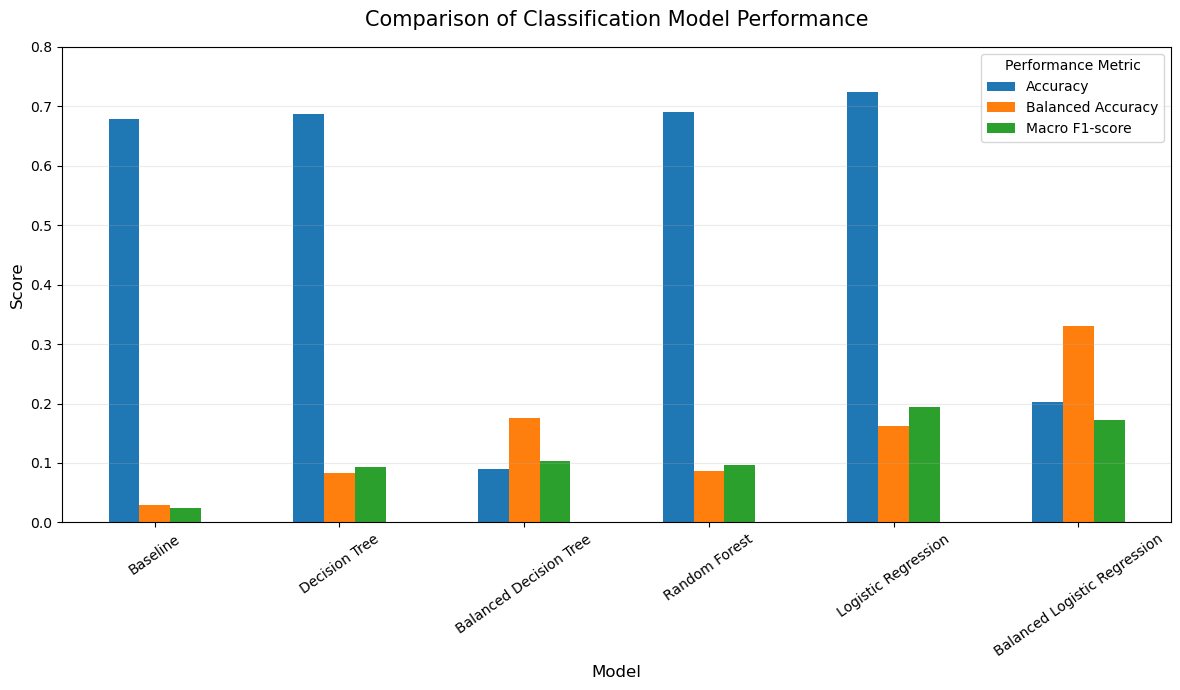

In [96]:
comparison_plot = final_model_comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title(
    "Comparison of Classification Model Performance",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_ylim(0, 0.80)

ax.tick_params(
    axis="x",
    rotation=35
)

ax.legend(
    title="Performance Metric"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    images_dir / "final_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.21 Final Model Selection

Across the models evaluated, **Logistic Regression** provides the strongest overall balance of predictive performance.

It achieved the highest overall accuracy at approximately **72.46%** and the highest macro F1-score at approximately **19.36%**. Its balanced accuracy of approximately **16.22%** was also substantially higher than that of the baseline, Decision Tree, and Random Forest models.

The **Balanced Logistic Regression** achieved the highest balanced accuracy at approximately **33.12%**, demonstrating much stronger recognition of minority cuisine classes. However, this improvement was accompanied by a substantial reduction in overall accuracy to approximately **20.32%** and a slightly lower macro F1-score of approximately **17.17%**.

The comparison therefore demonstrates a clear trade-off between overall predictive accuracy and equal treatment of minority classes. For this project, the ordinary **Logistic Regression model is retained as the primary model** because it provides the best overall combination of accuracy, macro F1-score, interpretability, and multiclass predictive performance.

Nevertheless, the relatively low balanced accuracy and weak performance for several minority cuisines indicate that the model should not be interpreted as equally reliable across all cuisine categories. Class imbalance remains the principal limitation of the modelling exercise and should be addressed in future model development.

## 8.0 Conclusions and Key Findings

This project investigated whether the cuisine of a recipe could be predicted from its ingredient profile using supervised machine learning.

The analysis used a dataset containing **57,691 recipes and 383 ingredient indicators**. After standardizing cuisine labels and excluding cuisine categories represented by 50 or fewer recipes, the analytical dataset contained **57,403 recipes across 34 cuisine categories**.

Exploratory analysis showed that the dataset is highly imbalanced, with American cuisine accounting for approximately **70% of the observations**. Common ingredients such as egg, wheat, butter, onion and garlic appeared frequently across many recipes, while cuisine-specific analysis revealed more distinctive ingredient patterns. Examples included olive oil and parmesan cheese for Italian cuisine, cayenne and cumin for Mexican cuisine, turmeric and cardamom for Indian cuisine, and soy sauce and sesame oil for Chinese and Japanese cuisines.

Several classification approaches were evaluated, including a baseline classifier, Decision Tree, class-balanced Decision Tree, Random Forest, Logistic Regression, and class-balanced Logistic Regression.

Among the models tested, the ordinary **Logistic Regression model produced the strongest overall performance**, achieving:

- **Accuracy:** 72.46%
- **Balanced Accuracy:** 16.22%
- **Macro F1-score:** 19.36%

The class-balanced Logistic Regression model achieved the highest balanced accuracy of **33.12%**, demonstrating substantially stronger recognition of minority cuisine categories. However, this came at the cost of a major reduction in overall accuracy to **20.32%**.

Cuisine-level evaluation showed that the ordinary Logistic Regression model performed particularly well for American, Indian and Mexican cuisines, while several smaller cuisine categories remained difficult to classify reliably. The confusion matrix also demonstrated a strong tendency to classify uncertain recipes as American, reflecting the dominance of the majority class.

Model coefficient analysis showed that Logistic Regression learned meaningful cuisine-specific ingredient relationships. For example, parmesan cheese and olive oil were strong predictors of Italian cuisine; tequila, cayenne and avocado were important for Mexican cuisine; cardamom and turmeric for Indian cuisine; and seaweed, sake and soy sauce for Japanese cuisine.

Overall, the findings demonstrate that **recipe ingredients contain useful information for predicting cuisine**, but classification performance is strongly affected by class imbalance and overlapping ingredient patterns across cuisine categories.

### 8.1 Limitations of the Analysis

Several limitations should be considered when interpreting the results of this project.

First, the dataset is **highly imbalanced**, with American cuisine accounting for approximately 70% of the analytical observations. This imbalance influenced model behaviour and contributed to the tendency of several classifiers to favour the majority class.

Second, the dataset represents ingredients as **binary indicators of presence or absence**. It does not include ingredient quantities, preparation methods, cooking techniques, serving style, or other contextual information that may help distinguish cuisines with similar ingredient profiles.

Third, some cuisine categories may overlap conceptually or geographically. Categories such as Asian, East Asian, Chinese, Japanese and Korean can share many ingredients, making classification more difficult when only ingredient presence is available.

Fourth, several cuisine categories contained relatively small numbers of observations even after cuisines with 50 or fewer recipes were excluded. Consequently, performance estimates for some minority classes are based on comparatively small test samples and should therefore be interpreted cautiously.

Fifth, cuisine labels were standardized during data preparation because the original dataset contained several inconsistent or overlapping country and cuisine names. Although this improved consistency, some category harmonization decisions may affect the interpretation of class-level results.

Finally, the modelling exercise evaluated a limited set of classification algorithms and did not undertake extensive hyperparameter optimization. Additional models, resampling approaches, feature engineering methods and systematic model tuning could potentially improve performance, particularly for minority cuisine categories.

### 8.2 Recommendations and Future Improvements

Several improvements could strengthen future versions of the cuisine classification model.

First, future modelling should address the severe class imbalance more systematically. Techniques such as oversampling minority classes, undersampling the dominant class, or using algorithms specifically designed to handle imbalanced data could be explored.

Second, feature engineering could be expanded beyond simple ingredient presence. Additional information such as ingredient quantities, preparation methods, cooking techniques, ingredient combinations and recipe text could provide richer signals for distinguishing cuisines with similar ingredient profiles.

Third, additional classification algorithms should be evaluated. Potential approaches include gradient boosting models, support vector machines and other ensemble methods. These models may capture more complex relationships among ingredients than the models evaluated in this project.

Fourth, systematic hyperparameter tuning using cross-validation could be undertaken to improve model performance and reduce reliance on a single train-test split.

Fifth, future work could investigate whether some overlapping cuisine categories should be reorganized into broader regional groups or hierarchical classifications. For example, a two-stage model could first predict a broad regional cuisine category and then predict a more specific cuisine within that region.

Sixth, evaluation should continue to emphasize metrics that account for class imbalance, including balanced accuracy, macro F1-score, class-level precision and recall, rather than relying on overall accuracy alone.

Finally, the project could be extended into a practical application in which a user enters a list of ingredients and receives predicted cuisine probabilities together with the ingredients that contributed most strongly to the prediction.

### 8.3 Portfolio Summary

This project applied supervised machine learning to predict recipe cuisine from ingredient presence using a dataset of **57,691 recipes and 383 ingredient variables**.

After cleaning and standardizing cuisine labels, the analysis focused on **57,403 recipes across 34 cuisine categories**. Exploratory analysis identified strong class imbalance and revealed both common and cuisine-specific ingredient patterns.

Six classification approaches were evaluated:

- Baseline classifier
- Decision Tree
- Class-Balanced Decision Tree
- Random Forest
- Logistic Regression
- Class-Balanced Logistic Regression

The ordinary **Logistic Regression model achieved the strongest overall performance**, with an accuracy of **72.46%**, balanced accuracy of **16.22%**, and macro F1-score of **19.36%**.

The project also demonstrated the importance of interpreting multiple evaluation metrics in imbalanced classification problems. Although class-balanced Logistic Regression substantially improved minority-class recognition, this came at a major cost to overall accuracy.

Model interpretation showed that ingredients such as parmesan cheese, olive oil, tequila, cardamom, turmeric, soy sauce, seaweed and sake contributed strongly to distinguishing selected cuisine categories.

The project demonstrates skills in:

- Data cleaning and preparation
- Exploratory data analysis
- Feature interpretation
- Multiclass classification
- Class imbalance analysis
- Model evaluation and comparison
- Confusion matrix analysis
- Model interpretability
- Data visualization
- Reproducible analysis using Python and Jupyter Notebook

In [97]:
readme_path = project_root / "README.md"

readme_content = """# Cuisine Classification Using Recipe Ingredients

## Overview

This project applies supervised machine learning to predict the cuisine of a recipe based on the ingredients used.

The analysis was developed from coursework undertaken as part of the IBM Data Science Professional Certificate and expanded into a complete portfolio project covering data understanding, data preparation, exploratory analysis, modelling, evaluation, model interpretation, and reproducibility.

The project demonstrates how ingredient patterns can be used to distinguish among cuisine categories while also highlighting the challenges created by severe class imbalance.

## Business Question

**Can the cuisine of a recipe be automatically predicted from the ingredients used in the recipe?**

This was formulated as a supervised multiclass classification problem in which:

- **Target:** Cuisine
- **Predictors:** 383 binary ingredient indicators
- **Unit of analysis:** Individual recipe

## Dataset

The original dataset contains:

- **57,691 recipes**
- **384 variables**
- **1 cuisine variable**
- **383 ingredient indicators**

Ingredient variables indicate whether a particular ingredient is present in a recipe.

After standardizing cuisine labels and excluding categories represented by 50 or fewer recipes, the analytical dataset contained:

- **57,403 recipes**
- **34 cuisine categories**
- **383 ingredient predictors**

Exact duplicate observations were retained during exploratory analysis but removed from the modelling dataset to reduce the possibility of identical ingredient profiles appearing in both the training and test sets.

## Project Workflow

The project follows a structured data science workflow:

1. Business understanding
2. Data understanding
3. Data loading and inspection
4. Data quality assessment
5. Data preparation
6. Exploratory data analysis
7. Machine learning modelling
8. Model evaluation and interpretation
9. Conclusions and recommendations

## Exploratory Analysis

The dataset is highly imbalanced, with American cuisine representing approximately 70% of the analytical observations.

Frequently occurring ingredients include:

- Egg
- Wheat
- Butter
- Onion
- Garlic
- Milk
- Vegetable oil
- Cream
- Tomato
- Olive oil

Cuisine-specific analysis revealed distinctive ingredient patterns. Examples include:

- **Italian:** olive oil, parmesan cheese, basil
- **Mexican:** cayenne, cumin, cilantro, avocado
- **Indian:** turmeric, cardamom, cumin, coriander
- **Chinese:** soy sauce, sesame oil, ginger
- **Japanese:** seaweed, sake, soy sauce, kelp

## Models Evaluated

Six classification approaches were compared:

- Baseline classifier
- Decision Tree
- Class-Balanced Decision Tree
- Random Forest
- Logistic Regression
- Class-Balanced Logistic Regression

## Model Performance

| Model | Accuracy | Balanced Accuracy | Macro F1 |
|---|---:|---:|---:|
| Baseline | 0.6788 | 0.0294 | 0.0238 |
| Decision Tree | 0.6876 | 0.0834 | 0.0932 |
| Balanced Decision Tree | 0.0901 | 0.1751 | 0.1027 |
| Random Forest | 0.6900 | 0.0860 | 0.0962 |
| Logistic Regression | **0.7246** | 0.1622 | **0.1936** |
| Balanced Logistic Regression | 0.2032 | **0.3312** | 0.1717 |

The ordinary **Logistic Regression model** was retained as the primary model because it provided the strongest overall balance between predictive accuracy, macro F1-score, interpretability, and multiclass performance.

The class-balanced Logistic Regression substantially improved minority-class recognition but produced a major reduction in overall accuracy.

## Key Findings

- Recipe ingredients contain useful information for predicting cuisine.
- Logistic Regression outperformed the tree-based models on overall accuracy and macro F1-score.
- Severe class imbalance strongly influenced model behaviour.
- The model performed particularly well for American, Indian, and Mexican cuisines.
- Several minority cuisine categories remained difficult to classify reliably.
- Ingredient prevalence and predictive importance are not necessarily the same.
- Logistic Regression coefficients provided interpretable cuisine-specific ingredient signals.

## Model Interpretation

Examples of ingredients receiving strong positive Logistic Regression coefficients include:

- **Italian:** parmesan cheese, olive oil
- **Mexican:** tequila, cayenne, avocado
- **Indian:** cardamom, turmeric, cumin
- **Chinese:** soy sauce, star anise, sesame oil
- **Japanese:** seaweed, sake, soy sauce, kelp

These coefficients indicate predictive association rather than causation.

## Visualisations

The project produces several portfolio-quality visualisations, including:

- Cuisine distribution
- Top ingredients
- Cuisine ingredient profiles
- Distinctive ingredient lift
- Decision Tree confusion matrix
- Logistic Regression confusion matrix
- Predictive ingredient coefficients
- Final model performance comparison

Generated figures are stored in the `images/` directory.

## Technologies Used

- Python
- Jupyter Notebook
- pandas
- NumPy
- Matplotlib
- scikit-learn

## Project Structure

```text
cuisine-classification/
│
├── README.md
├── data/
│   └── recipes.csv
├── images/
├── notebooks/
│   └── cuisine_classification.ipynb
└── docs/

_IncompleteInputError: incomplete input (492012491.py, line 3)